In [1]:
from CRNs import *
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


Network data length: 50001


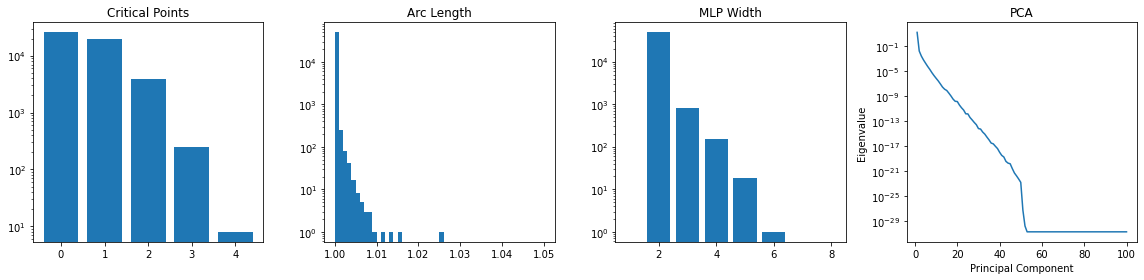

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr0_l/"
param1_values = ["1", "2", "3", "4", "11", "22", "33", "44"]
pv = "44"

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))

file = path + pv + "/critical_points.pkl"
with open(file, "rb") as f:
    data = pickle.load(f)

network_data = data['network_data']
print(f"Network data length: {len(network_data)}")

# Examine the result_value tuple safely
network = network_data[0]
results_list = [network_data[i]['result_value'][0] for i in range(len(network_data) - 1)]
valid_results = [x for x in results_list if x is not None]

ax1.hist(valid_results, bins=range(min(valid_results), max(valid_results) + 2, 1), align='left', rwidth=0.8)
ax1.set_yscale('log')
ax1.set_title('Critical Points')

file = path + pv + "/arc_length.pkl"
with open(file, "rb") as f:
    data = pickle.load(f)

network_data = data['network_data']
results_list = [network_data[i]['result_value'] for i in range(len(network_data) - 1)]
valid_results = [x for x in results_list if x is not None]
bins = np.linspace(1.0, 1.05, 51) 

ax2.hist(valid_results, bins = bins)
ax2.set_yscale('log')
ax2.set_title('Arc Length')


# file = path + pv + "/mlp_width.pkl"
# with open(file, "rb") as f:
#     data = pickle.load(f)

# network_data = data['network_data']

# # Examine the result_value tuple safely
# network = network_data[0]
# results_list = [network_data[i]['result_value'] for i in range(len(network_data) - 1)]
# valid_results = [x for x in results_list if x is not None]

# min_width = 1
# max_width = 8
# ax3.hist(valid_results, bins=range(min_width, max_width + 1, 1), align='left', rwidth=0.8)
# ax3.set_yscale('log')
# ax3.set_title('MLP Width')
# ax3.set_xlim(min_width - 0.5, max_width + 0.5)


file = path + pv + "/pca.pkl"
with open(file, "rb") as f:
    data = pickle.load(f)

# Get the eigenvalues (principal component values)
pc_values = data['network_data'][0]['result_value']['explained_variance']

# Plot principal component values in descending order on ax4
ax4.plot(range(1, len(pc_values)+1), pc_values, '-', label=f'pv={pv}')
ax4.set_yscale('log')
ax4.set_title('PCA')
ax4.set_xlabel('Principal Component')
ax4.set_ylabel('Eigenvalue')

plt.tight_layout()

1
1
2
2
3
3
4
4
5
5


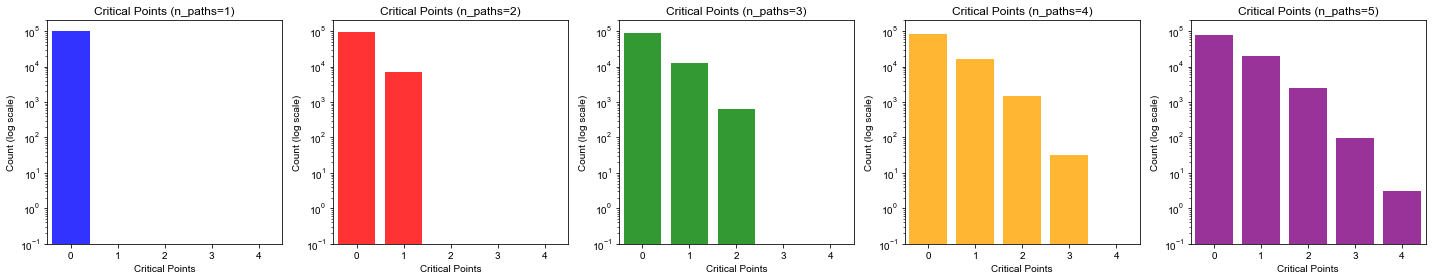

In [73]:
plt.rcParams['font.family'] = 'Arial'

# Plot multiple pv values in a horizontal grid layout with consistent axis limits
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr0_width_bigwide/"
#path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/coupling_scan_depth_short2/"
pv_sublist = ["1", "2", "3", "4", "5"]  # Define which pv values to plot
#pv_sublist = ["n", "1", "11"]  # Define which pv values to plot
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']  # Color options

# Predefine axis limits for consistency
critical_points_xlim = (-0.5, 4.5)  # Adjust based on your data range
critical_points_ylim = (0.1, 2e5)  # Adjust based on your data range

arc_length_xlim = (1.0, 1.05)
arc_length_ylim = (1, 6e4)  # Adjust based on your data range

tac_length_xlim = (0, 0.3)
tac_length_ylim = (1, 6e4)  # Adjust based on your data range

mlp_width_xlim = (0.5, 8.5)
mlp_width_ylim = (1, 6e4)  # Adjust based on your data range

n_pv = len(pv_sublist)
fig, axes = plt.subplots(1, n_pv, figsize=(4*n_pv, 4))  # Horizontal layout (1 row, n_pv columns)

# If only one pv value, ensure axes is a list for consistent indexing
if n_pv == 1:
    axes = [axes]

valid_results_dict = {}
n_paths_dict = {}
# Plot for each pv value
for i, pv in enumerate(pv_sublist):
    # Critical Points
    ax1 = axes[i]
    file = path + pv + "/critical_points.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        
        network_data = data['network_data']
        results_list = [network_data[j]['result_value'][0] for j in range(len(network_data) - 1)]
        valid_results = [x for x in results_list if x is not None]
        valid_results_dict[pv] = valid_results
        n_paths_list = [network_data[j]['n_paths'] for j in range(len(network_data) - 1)]
        n_paths_dict[pv] = n_paths_list
        print(max(n_paths_list))
        print(min(n_paths_list))
        
        if valid_results:
            ax1.hist(valid_results, bins=range(min(valid_results), max(valid_results) + 2, 1), 
                    align='left', rwidth=0.8, color=colors[i % len(colors)], alpha=0.8)
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")

    ax1.set_yscale('log')
    ax1.set_title(f'Critical Points (n_paths={max(n_paths_list)})')
    ax1.set_xlabel('Critical Points')
    ax1.set_ylabel('Count (log scale)')
    ax1.set_xlim(critical_points_xlim)
    ax1.set_ylim(critical_points_ylim)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


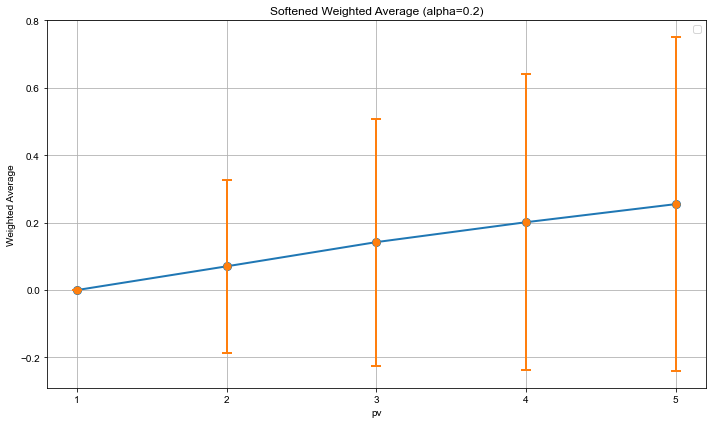

In [35]:
import numpy as np

def softened_stats(samples, alpha, min_val=None, max_val=None):
    """
    Compute softened-weight mean and standard deviation over integer samples.

    samples : 1D array of integers
    alpha   : float
    """
    samples = np.asarray(samples, dtype=int)

    # Determine histogram support
    if min_val is None:
        min_val = samples.min()
    if max_val is None:
        max_val = samples.max()

    # Histogram
    bins = np.arange(min_val, max_val + 2)
    freq, _ = np.histogram(samples, bins=bins)
    values = np.arange(min_val, max_val + 1)

    # Softened weights
    softened = freq.astype(float)**alpha
    Z = softened.sum()
    if Z == 0:
        return np.nan, np.nan

    w = softened / Z

    # Weighted mean
    mean = np.sum(values * w)

    # Weighted variance (population version)
    var = np.sum((values - mean)**2 * w)

    return freq, mean, np.sqrt(var)

# Collect frequency data for each pv value
freqs_dict = {}
values_dict = {}
for pv in pv_sublist:
    freq, values, _ = softened_weighted_average(valid_results_dict[pv], 1)
    freqs_dict[pv] = freq
    values_dict[pv] = values

# Determine the full range of integer values across all pv
all_values = set()
for values in values_dict.values():
    all_values.update(values)
all_values = sorted(all_values)

# Create a dictionary mapping each integer to its occurrences across pv values
occurrences_by_integer = {val: [] for val in all_values}

for pv in pv_sublist:
    values = values_dict[pv]
    freq = freqs_dict[pv]
    
    # Create a mapping from value to frequency for this pv
    value_to_freq = dict(zip(values, freq))
    
    # For each integer, record its frequency (0 if not present)
    for val in all_values:
        occurrences_by_integer[val].append(value_to_freq.get(val, 0))

# Plot line plots for each integer
plt.figure(figsize=(10, 6))

alpha = 1
averages = [softened_stats(valid_results_dict[pv], alpha)[1] for pv in pv_sublist]
stds = [softened_stats(valid_results_dict[pv], alpha)[2] for pv in pv_sublist]
plt.plot(pv_sublist, averages, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.errorbar(pv_sublist, averages, yerr=stds, fmt='o', capsize=5, elinewidth=2, markeredgewidth=2)
plt.xlabel('pv')
plt.ylabel('Weighted Average')
plt.title('Softened Weighted Average (alpha=0.2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




# # Plot line plots for each integer
# plt.figure(figsize=(10, 6))
# pv_numeric = [int(pv) for pv in pv_sublist]  # Convert pv to numeric for plotting

# for val in all_values:
#     plt.plot(pv_numeric, occurrences_by_integer[val], marker='o', linestyle='-', 
#              linewidth=2, markersize=6, label=f'Value {val}')

# plt.xlabel('pv')
# plt.ylabel('Number of Occurrences')
# plt.title('Occurrences of Each Integer Value vs pv')
# plt.yscale('log')
# plt.ylim(1, 2e5)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


In [ ]:
pv_sublist = [str(a) + "_" + str(b) for a in range(1, 6) for b in range(1, 4)]
print(pv_sublist)

['1_1', '1_2', '2_1', '2_2', '3_1', '3_2', '4_1', '4_2', '5_1', '5_2']


1
1
2
2
3
3
1
1
1
1
2
2
4
4
3
3
3
3
2
2
0
0
4
4
2
2
1
1
2
2


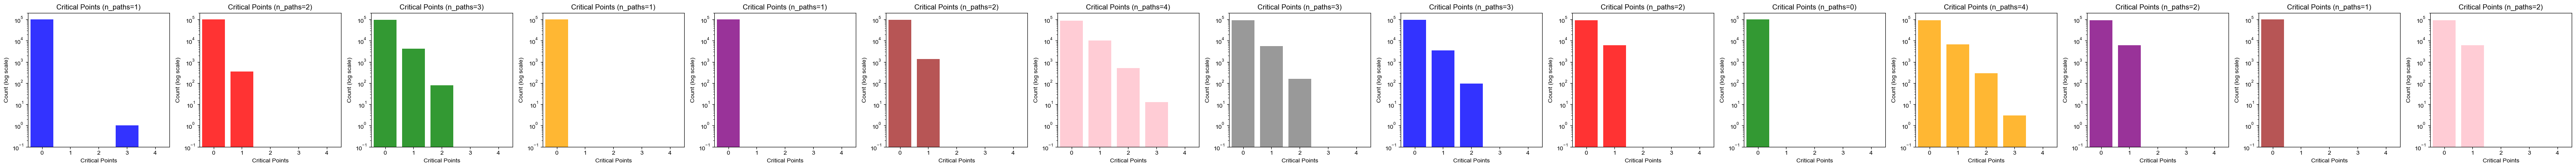

In [7]:
plt.rcParams['font.family'] = 'Arial'

# Plot multiple pv values in a horizontal grid layout with consistent axis limits
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr0_width_bigwide/"
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/dag_n_paths_idx_NS4_big_pr1/"
#path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/coupling_scan_depth_short2/"
pv_sublist = ["1", "2", "3", "4", "5"]  # Define which pv values to plot
pv_sublist = [str(a) + "_" + str(b) for a in range(1, 6) for b in range(1, 4)]
#pv_sublist = ["n", "1", "11"]  # Define which pv values to plot
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']  # Color options

# Predefine axis limits for consistency
critical_points_xlim = (-0.5, 4.5)  # Adjust based on your data range
critical_points_ylim = (0.1, 2e5)  # Adjust based on your data range

arc_length_xlim = (1.0, 1.05)
arc_length_ylim = (1, 6e4)  # Adjust based on your data range

tac_length_xlim = (0, 0.3)
tac_length_ylim = (1, 6e4)  # Adjust based on your data range

mlp_width_xlim = (0.5, 8.5)
mlp_width_ylim = (1, 6e4)  # Adjust based on your data range

n_pv = len(pv_sublist)
fig, axes = plt.subplots(1, n_pv, figsize=(4*n_pv, 4))  # Horizontal layout (1 row, n_pv columns)

# If only one pv value, ensure axes is a list for consistent indexing
if n_pv == 1:
    axes = [axes]

# Plot for each pv value
for i, pv in enumerate(pv_sublist):
    # Critical Points
    ax1 = axes[i]
    file = path + pv + "/critical_points.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        
        network_data = data['network_data']
        results_list = [network_data[j]['result_value'][0] for j in range(len(network_data) - 1)]
        valid_results = [x for x in results_list if x is not None]
        n_paths_list = [network_data[j]['n_paths'] for j in range(len(network_data) - 1)]
        #adjacency_matrix = network_data['adjacency_matrix']
        print(max(n_paths_list))
        print(min(n_paths_list))
        
        if valid_results:
            ax1.hist(valid_results, bins=range(min(valid_results), max(valid_results) + 2, 1), 
                    align='left', rwidth=0.8, color=colors[i % len(colors)], alpha=0.8)
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")

    ax1.set_yscale('log')
    ax1.set_title(f'Critical Points (n_paths={max(n_paths_list)})')
    ax1.set_xlabel('Critical Points')
    ax1.set_ylabel('Count (log scale)')
    ax1.set_xlim(critical_points_xlim)
    ax1.set_ylim(critical_points_ylim)

plt.tight_layout()
plt.show()

['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '3_1', '3_2', '3_3', '4_1', '4_2', '4_3', '5_1', '5_2', '5_3']
pv=1_1: max n_paths=1, min n_paths=1
pv=1_2: max n_paths=1, min n_paths=1
pv=1_3: max n_paths=1, min n_paths=1
pv=2_1: max n_paths=2, min n_paths=2
pv=2_2: max n_paths=2, min n_paths=2
pv=2_3: max n_paths=2, min n_paths=2
pv=3_1: max n_paths=3, min n_paths=3
pv=3_2: max n_paths=3, min n_paths=3
pv=3_3: max n_paths=3, min n_paths=3
pv=4_1: max n_paths=4, min n_paths=4
pv=4_2: max n_paths=4, min n_paths=4
pv=4_3: max n_paths=4, min n_paths=4
pv=5_1: max n_paths=5, min n_paths=5
pv=5_2: max n_paths=5, min n_paths=5
pv=5_3: max n_paths=5, min n_paths=5


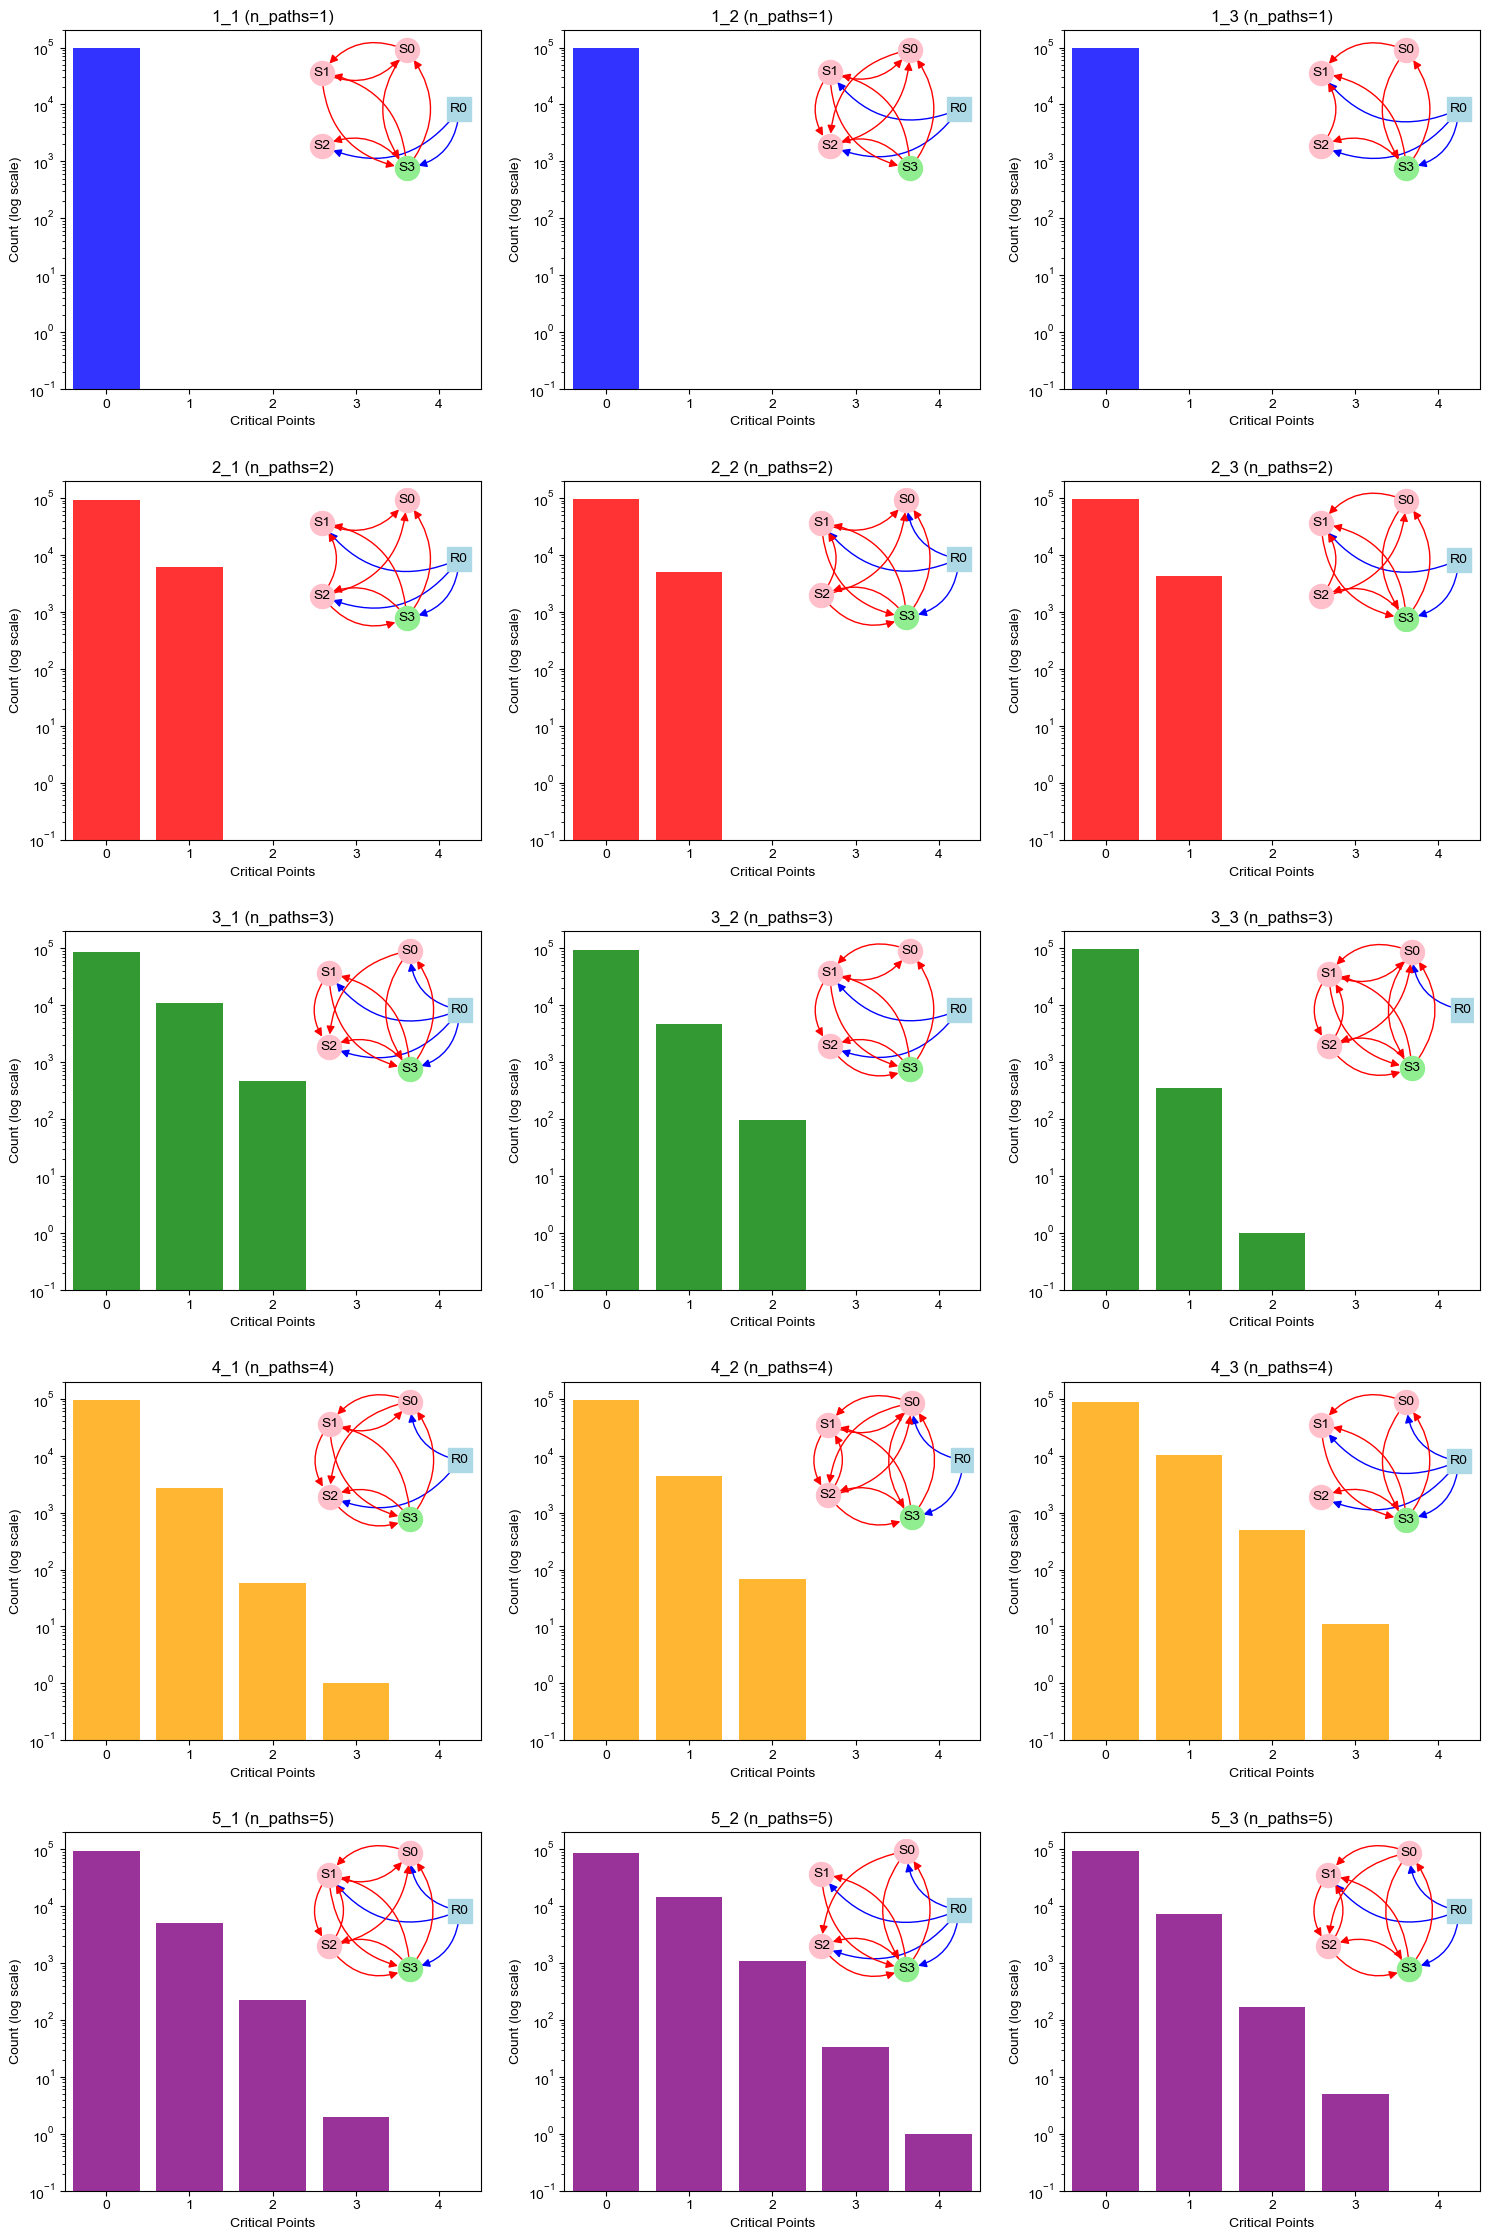

In [49]:
def visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, node_size=600, arrow_size=25, font_size=12, ax=None):
    """
    Visualize the DAG signaling network including receptor connections.
    
    Args:
        adjacency_matrix: The adjacency matrix for substrate-substrate connections
        input_substrates_list: List of substrate indices that are input substrates
        NR: Number of receptors
        NS: Number of substrates
        ax: Optional matplotlib axis to plot into. If None, creates a new figure and axis.

        title: Title for the plot
        
    Returns:
        matplotlib figure object (if ax is None) or the provided axis
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    
    # Create a directed graph
    G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
       
    # Create the plot if axis not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
        return_fig = True
    else:
        fig = ax.get_figure()
        return_fig = False

    #print(nx.is_directed_acyclic_graph(G))
    if nx.is_directed_acyclic_graph(G):

        for layer, nodes in enumerate(nx.topological_generations(G)):
        # `multipartite_layout` expects the layer as a node attribute, so add the
        # numeric layer value as a node attribute
            for node in nodes:
                G.nodes[node]["layer"] = layer

        # Check if G is a directed acyclic graph
    
        # If DAG, use multipartite layout
        pos = nx.multipartite_layout(G, subset_key="layer")
        rotation_matrix = np.array([[0, 1], [-1, 0]])  # 90 degree counterclockwise rotation
        for node in pos:
            pos[node] = rotation_matrix @ np.array(pos[node])
    else:
        # If not DAG, use spring layout
        #pos = nx.spring_layout(G, k=2, iterations=50)
        pos = nx.circular_layout(G)
    
    # Draw nodes
    receptor_nodes = [node for node in G.nodes() if node.startswith('R')]
    substrate_nodes = [node for node in G.nodes() if node.startswith('S')]
    
    nx.draw_networkx_nodes(G, pos, nodelist=receptor_nodes, 
                          node_color='lightblue', node_size=node_size, 
                          node_shape='s', ax=ax, label='Receptors')
    nx.draw_networkx_nodes(G, pos, nodelist=substrate_nodes[:-1], 
                          node_color='pink', node_size=node_size, 
                          node_shape='o', ax=ax, label='Substrates')
    nx.draw_networkx_nodes(G, pos, nodelist=substrate_nodes[-1:], 
                          node_color='lightgreen', node_size=node_size, 
                          node_shape='o', ax=ax, label='Substrates')
    
    # Draw edges with different colors
    receptor_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'receptor']
    substrate_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'substrate']
    
    nx.draw_networkx_edges(G, pos, edgelist=receptor_edges, 
                          edge_color='blue', arrows=True, arrowsize=arrow_size, 
                          ax=ax, label='Receptor activation', connectionstyle="arc3,rad=-0.4")
    nx.draw_networkx_edges(G, pos, edgelist=substrate_edges, 
                          edge_color='red', arrows=True, arrowsize=arrow_size, 
                          ax=ax, label='Substrate catalysis', connectionstyle="arc3,rad=0.4")
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size, font_family='Arial')
    
    if return_fig:
        plt.tight_layout()
        return fig
    else:
        return ax




plt.rcParams['font.family'] = 'Arial'

# Set up parameters and data
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/dag_n_paths_idx_NS4_big_pr1/"
pv_sublist = [str(a) + "_" + str(b) for a in range(1, 6) for b in range(1, 4)]  # 5 rows (a), 3 cols (b)
print(pv_sublist)
pr = 1.0

# Gather axes network data for all pv values
axes_data = []
for pv in pv_sublist:
    file = path + pv + "/critical_points.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        network_data = data['network_data']
        input_substrates_list = network_data[-1]['input_substrates_list']
        adjacency_matrix = network_data[-1]['adjacency_matrix']
        NR = network_data[-1]['NR']
        NS = network_data[-1]['NS']
        axes_data.append(dict(
            pv=pv,
            adjacency_matrix=adjacency_matrix,
            input_substrates_list=input_substrates_list,
            NR=NR,
            NS=NS
        ))
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
        axes_data.append(None)
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")
        axes_data.append(None)

valid_axes_data = [d for d in axes_data if d is not None]
num_valid = len(valid_axes_data)

# Predefine axis limits for consistency
critical_points_xlim = (-0.5, 4.5)
critical_points_ylim = (0.1, 2e5)
arc_length_xlim = (1.0, 1.05)
arc_length_ylim = (1, 6e4)
tac_length_xlim = (0, 0.3)
tac_length_ylim = (1, 6e4)
mlp_width_xlim = (0.5, 8.5)
mlp_width_ylim = (1, 6e4)

valid_results_dict = {}
n_paths_dict = {}

if num_valid > 0:
    n_rows, n_cols = 5, 3
    # Validate shape
    assert len(valid_axes_data) == n_rows * n_cols, "pv_sublist must have 15 entries for 5x3 grid."
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape((n_rows, n_cols))
    axes = np.atleast_2d(axes)

    for idx, (d, pv) in enumerate(zip(valid_axes_data, pv_sublist)):
        row = idx // n_cols
        col = idx % n_cols
        ax_hist = axes[row, col]
        file = path + pv + "/critical_points.pkl"
        try:
            with open(file, "rb") as f:
                data = pickle.load(f)
            network_data = data['network_data']
            results_list = [network_data[j]['result_value'][0] for j in range(len(network_data) - 1)]
            valid_results = [x for x in results_list if x is not None]
            valid_results_dict[pv] = valid_results
            n_paths_list = [network_data[j]['n_paths'] for j in range(len(network_data) - 1)]
            n_paths_dict[pv] = n_paths_list
            # Print n_paths stats
            print(f"pv={pv}: max n_paths={max(n_paths_list)}, min n_paths={min(n_paths_list)}")
            if valid_results:
                bins = range(min(valid_results), max(valid_results) + 2, 1)
                color = colors[row % len(colors)]
                ax_hist.hist(valid_results, bins=bins, align='left', rwidth=0.8,
                             color=color, alpha=0.8)
            ax_hist.set_yscale('log')
            ax_hist.set_title(f'{pv} (n_paths={max(n_paths_list)})', fontsize=12)
            ax_hist.set_xlabel('Critical Points')
            ax_hist.set_ylabel('Count (log scale)')
            ax_hist.set_xlim(critical_points_xlim)
            ax_hist.set_ylim(critical_points_ylim)
        except FileNotFoundError:
            print(f"File not found for pv={pv}: {file}")
            ax_hist.set_title(f"{pv}: Missing data")
        except Exception as e:
            print(f"Error processing pv={pv}: {e}")
            ax_hist.set_title(f"{pv}: Data error")

        # Inset axes for network drawing
        try:
            # smaller inset at top right, no border
            from mpl_toolkits.axes_grid1.inset_locator import inset_axes
            ax_inset = inset_axes(ax_hist, width="40%", height="40%", loc='upper right', borderpad=0.5)
            # Remove black border around inset
            for spine in ax_inset.spines.values():
                spine.set_visible(False)
            visualize_dag_signaling_network(
                d['adjacency_matrix'],
                d['input_substrates_list'],
                d['NR'],
                d['NS'],
                node_size=300,
                arrow_size=12,
                font_size=10,
                ax=ax_inset
            )
            ax_inset.set_xticks([])
            ax_inset.set_yticks([])
            ax_inset.set_xlabel("")
            ax_inset.set_ylabel("")
            ax_inset.set_title("", fontsize=8)
        except Exception as e:
            print(f"error in network inset for {pv}: {e}")

    plt.tight_layout(h_pad=2.3, w_pad=2.1)
    plt.show()

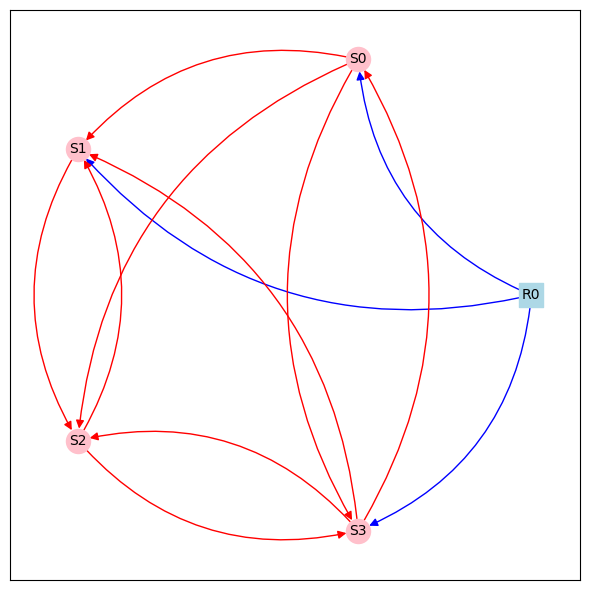

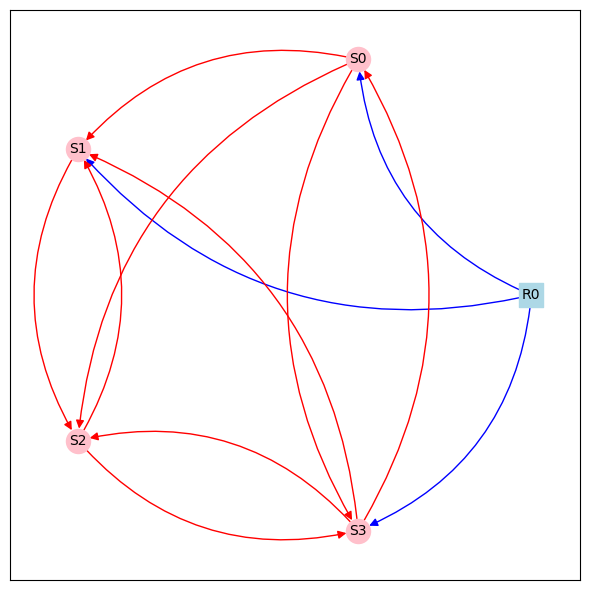

In [ ]:

         
visualize_dag_signaling_network(
    d['adjacency_matrix'],
    d['input_substrates_list'],
    d['NR'],
    d['NS'],
    node_size=300,
    arrow_size=12,
    font_size=10
)

In [ ]:
plt.rcParams['font.family'] = 'Arial'

# Set up parameters and data
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr0_width_bigwide/"
pv_sublist = ["1", "2", "3", "4", "5"]


# path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/coupling_scan_depth_short2/"
# pv_sublist = ["n", "1"]  # Define which pv values to plot
# colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/dag_scan_seed_pr_noncon_3/"
#pv_sublist = ["1", "2", "3", "4", "5"]  # Define which pv values to plot
pv_sublist = ["11", "12", "13", "14", "15", "16", "17", "18", "19", "20"]
pv_sublist = ["21", "22", "23", "24", "25", "26", "27", "28", "29", "30"]

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/dag_n_paths_idx_NS4_big_pr1/"
#path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/coupling_scan_depth_short2/"
pv_sublist = ["1", "2", "3", "4", "5"]  # Define which pv values to plot
pv_sublist = [str(a) + "_" + str(b) for a in range(1, 6) for b in range(1, 4)]
print(pv_sublist)
pr = 1.0

# Gather axes network data for all pv values
axes_data = []
for pv in pv_sublist:
    file = path + pv + "/critical_points.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        network_data = data['network_data']
        input_substrates_list = network_data[-1]['input_substrates_list']
        adjacency_matrix = network_data[-1]['adjacency_matrix']
        NR = network_data[-1]['NR']
        NS = network_data[-1]['NS']
        axes_data.append(dict(
            pv=pv,
            adjacency_matrix=adjacency_matrix,
            input_substrates_list=input_substrates_list,
            NR=NR,
            NS=NS
        ))
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
        axes_data.append(None)
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")
        axes_data.append(None)

valid_axes_data = [d for d in axes_data if d is not None]
num_valid = len(valid_axes_data)

# Predefine axis limits for consistency
critical_points_xlim = (-0.5, 4.5)
critical_points_ylim = (0.1, 2e5)
arc_length_xlim = (1.0, 1.05)
arc_length_ylim = (1, 6e4)
tac_length_xlim = (0, 0.3)
tac_length_ylim = (1, 6e4)
mlp_width_xlim = (0.5, 8.5)
mlp_width_ylim = (1, 6e4)

valid_results_dict = {}
n_paths_dict = {}
# Create the shared figure with both the network visualizations and distributions all in one
if num_valid > 0:
    # Layout: 2 rows, n_pv columns. Top: network, bottom: histogram
    fig, axes = plt.subplots(2, num_valid, figsize=(5*num_valid, 10), gridspec_kw={"height_ratios": [2, 2]})
    if num_valid == 1:
        axes = np.array([[axes[0]], [axes[1]]])  # Make sure axes is 2D array

    for col, (d, pv) in enumerate(zip(valid_axes_data, pv_sublist)):
        ax_net = axes[0, col]
        ax_hist = axes[1, col]
        # --- Top row: network visualization ---
        try:
            visualize_dag_signaling_network(
                d['adjacency_matrix'],
                d['input_substrates_list'],
                d['NR'],
                d['NS'],
                ax=ax_net
            )
            ax_net.set_title(f"pv={d['pv']}", fontsize=13)
        except Exception as e:
            print(f"Error in plotting network for pv={d['pv']}: {e}")
            ax_net.set_title(f"pv={d['pv']} (error)", fontsize=13)

        # --- Bottom row: critical points histogram ---
        file = path + pv + "/critical_points.pkl"
        try:
            with open(file, "rb") as f:
                data = pickle.load(f)
            network_data = data['network_data']
            results_list = [network_data[j]['result_value'][0] for j in range(len(network_data) - 1)]
            valid_results = [x for x in results_list if x is not None]
            valid_results_dict[pv] = valid_results
            n_paths_list = [network_data[j]['n_paths'] for j in range(len(network_data) - 1)]
            n_paths_dict[pv] = n_paths_list
            # Print n_paths stats
            print(f"pv={pv}: max n_paths={max(n_paths_list)}, min n_paths={min(n_paths_list)}")

            if valid_results:
                bins = range(min(valid_results), max(valid_results) + 2, 1)
                ax_hist.hist(valid_results, bins=bins, align='left', rwidth=0.8,
                             color=colors[col % len(colors)], alpha=0.8)
            ax_hist.set_yscale('log')
            ax_hist.set_title(f'Critical Points (n_paths={max(n_paths_list)})')
            ax_hist.set_xlabel('Critical Points')
            ax_hist.set_ylabel('Count (log scale)')
            ax_hist.set_xlim(critical_points_xlim)
            ax_hist.set_ylim(critical_points_ylim)
        except FileNotFoundError:
            print(f"File not found for pv={pv}: {file}")
            ax_hist.set_title("Missing data")
        except Exception as e:
            print(f"Error processing pv={pv}: {e}")
            ax_hist.set_title("Data error")

    plt.tight_layout(h_pad=2.5)
    plt.show()

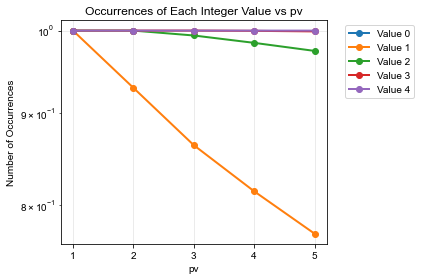

In [ ]:
import numpy as np

def softened_stats(samples, alpha, min_val=None, max_val=None):
    """
    Compute softened-weight mean and standard deviation over integer samples.

    samples : 1D array of integers
    alpha   : float
    """
    samples = np.asarray(samples, dtype=int)

    # Determine histogram support
    if min_val is None:
        min_val = samples.min()
    if max_val is None:
        max_val = samples.max()

    # Histogram
    bins = np.arange(min_val, max_val + 2)
    freq, _ = np.histogram(samples, bins=bins)
    values = np.arange(min_val, max_val + 1)

    # Softened weights
    softened = freq.astype(float)**alpha
    Z = softened.sum()
    if Z == 0:
        return np.nan, np.nan

    w = softened / Z

    # Weighted mean
    mean = np.sum(values * w)

    # Weighted variance (population version)
    var = np.sum((values - mean)**2 * w)

    return freq, values, mean, np.sqrt(var)

# Collect frequency data for each pv value
freqs_dict = {}
values_dict = {}
proportions_dict = {}
mean_values_dict = {}
geom_means_dict = {}
for pv in pv_sublist:
    freq, values, _, _ = softened_stats(valid_results_dict[pv], 1)
    freqs_dict[pv] = freq
    values_dict[pv] = values
    total_count = np.sum(freq)
    proportions_dict[pv] = freq / total_count
    mean_value = np.sum(values * freq) / total_count
    mean_values_dict[pv] = mean_value
    geom_mean = np.exp(np.sum(np.log(values+1) * freq) / total_count)-1
    geom_means_dict[pv] = geom_mean

# Determine the full range of integer values across all pv
all_values = set()
for values in values_dict.values():
    all_values.update(values)
all_values = sorted(all_values)

# Create a dictionary mapping each integer to its occurrences across pv values
occurrences_by_integer = {val: [] for val in all_values}
log_odds_ratio_by_integer = {val: [] for val in all_values}
tail_mass_by_integer = {val: [] for val in all_values}

for pv in pv_sublist:
    values = values_dict[pv]
    freq = freqs_dict[pv]
    
    # Create a mapping from value to frequency for this pv
    value_to_freq = dict(zip(values, freq))
    
    # Calculate total count for this pv
    total_count = np.sum(freq)
    
    # For each integer, record its frequency (0 if not present)
    for val in all_values:
        occurrences_by_integer[val].append(value_to_freq.get(val, 0))
        
        # Calculate log odds ratio: P(X >= k) / P(X < k)
        # P(X >= k) = sum of frequencies for values >= k
        p_geq_k = sum(value_to_freq.get(v, 0) for v in all_values if v >= val) / total_count
        # P(X < k) = sum of frequencies for values < k
        p_lt_k = sum(value_to_freq.get(v, 0) for v in all_values if v < val) / total_count
        
        # Compute log odds ratio with small epsilon to avoid division by zero
        epsilon = 0e-0
        lor = np.log((p_geq_k + epsilon) / (p_lt_k + epsilon))
        lor = (p_geq_k + epsilon) / (p_lt_k + epsilon)
        log_odds_ratio_by_integer[val].append(lor)

        # Calculate tail mass: P(X >= k)
        tail_mass = sum(value_to_freq.get(v, 0) for v in all_values if v >= val) / total_count
        tail_mass_by_integer[val].append(tail_mass)

# Calculate geometric means for each integer value
geometric_means = {}
for val in all_values:
    occurrences = np.array(occurrences_by_integer[val])
    # Add small epsilon to avoid log(0)
    occurrences_nonzero = occurrences[occurrences > 0]
    if len(occurrences_nonzero) > 0:
        geometric_means[val] = np.exp(np.mean(np.log(occurrences_nonzero)))
    else:
        geometric_means[val] = 0

# # Plot line plots for each integer
# plt.figure(figsize=(10, 6))
# pv_numeric = [int(pv) for pv in pv_sublist]  # Convert pv to numeric for plotting
# n_paths = [np.max(n_paths_dict[pv]) for pv in pv_sublist]

# plt.figure(figsize=(10, 6))
# plt.plot(n_paths, geom_means_dict.values(), marker='o', linestyle='-', 
#          linewidth=2, markersize=6, label='Geometric Mean')
# plt.xlabel('n_paths')
# plt.ylabel('Geometric Mean of Frequency')
# plt.title('Geometric Mean of Frequency Data Across n_paths Values')
# #plt.yscale('log')
# plt.grid(True, alpha=0.3, axis='y')
# plt.tight_layout()
# plt.show()

pv_numeric = [int(pv) for pv in pv_sublist]  # Convert pv to numeric for plotting
n_paths = [np.max(n_paths_dict[pv]) for pv in pv_sublist]

for val in all_values:
    plt.plot(n_paths, tail_mass_by_integer[val], marker='o', linestyle='-', 
             linewidth=2, markersize=6, label=f'Value {val}')

plt.xlabel('pv')
plt.ylabel('Number of Occurrences')
plt.title('Occurrences of Each Integer Value vs pv')
plt.yscale('log')
#plt.ylim(1, 2e5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Fitted parameters: n=1, p=0.0613
Mean of data: 0.0613, Mean of fit: 0.0613
max n_paths:  2


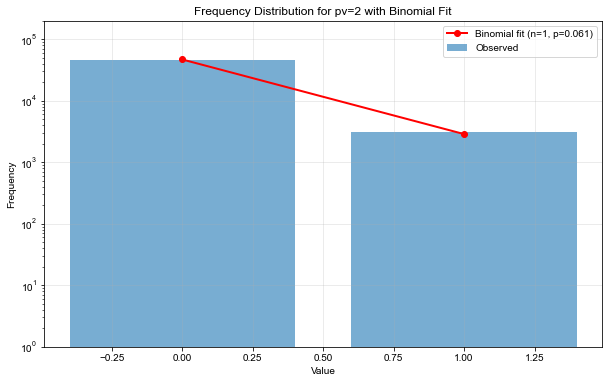

Fitted parameters: n=1, p=0.0613
Mean of data: 0.0613, Mean of fit: 0.0613


In [52]:
# Get the frequency data for pv="2"
pv = "3"
freq_data = freqs_dict[pv]
values_data = values_dict[pv]

# Fit binomial distribution
from scipy.stats import binom
from scipy.optimize import minimize

# Calculate mean and total count
total_count = np.sum(freq_data)
mean_value = np.sum(values_data * freq_data) / total_count

# Estimate n and p for binomial distribution
# mean = n*p, so we need to estimate both n and p
# Start with n as max value and p as mean/n
n_estimate = int(np.max(values_data))
p_estimate = mean_value / n_estimate if n_estimate > 0 else 0.5

# Optimize to find best fit
def neg_log_likelihood(params):
    n, p = int(params[0]), params[1]
    if n <= 0 or p <= 0 or p >= 1:
        return 1e10
    pmf_values = poisson.pmf(values_data, n)
    return -np.sum(freq_data * np.log(pmf_values + 1e-10))

result = minimize(neg_log_likelihood, [n_estimate, p_estimate], 
                  bounds=[(np.max(values_data), np.max(values_data)*2), (0.01, 0.99)])
n_fit, p_fit = int(result.x[0]), result.x[1]

# Generate fitted distribution
from scipy.stats import poisson
fitted_pmf = poisson.pmf(values_data, mean_value) * total_count
print(f"Fitted parameters: n={n_fit}, p={p_fit:.4f}")
print(f"Mean of data: {mean_value:.4f}, Mean of fit: {n_fit*p_fit:.4f}")
print("max n_paths: ", np.max(n_paths_dict[pv]))

# Plot histogram and fitted distribution
plt.figure(figsize=(10, 6))
plt.bar(values_data, freq_data, alpha=0.6, label='Observed', width=0.8)
plt.plot(values_data, fitted_pmf, 'r-', linewidth=2, marker='o', 
         label=f'Binomial fit (n={n_fit}, p={p_fit:.3f})')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title(f'Frequency Distribution for pv=2 with Binomial Fit')
plt.legend()
plt.yscale('log')
plt.ylim(1, 2e5)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fitted parameters: n={n_fit}, p={p_fit:.4f}")
print(f"Mean of data: {mean_value:.4f}, Mean of fit: {n_fit*p_fit:.4f}")

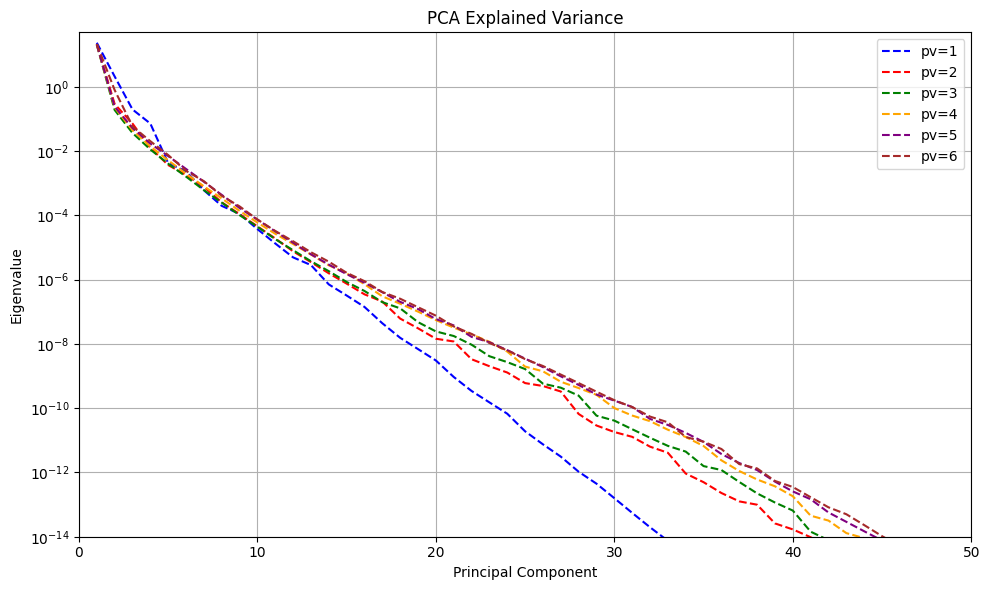

In [ ]:
# Plot PCA explained variances for multiple pv values
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr0_l/"
pv_sublist = ["1", "2", "3", "4", "5", "6"]  # Define which pv values to plot
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']  # Color options

# Create single panel plot
plt.figure(figsize=(10, 6))

# Plot PCA for each pv value
for i, pv in enumerate(pv_sublist):
    file = path + pv + "/pca.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        
        # Get the eigenvalues (principal component values)
        pc_values = data['network_data'][0]['result_value']['explained_variance']
        
        # Plot principal component values in descending order
        plt.plot(range(1, len(pc_values)+1), pc_values, '--', 
                color=colors[i % len(colors)], label=f'pv={pv}')
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")

# path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr1/"
# # Plot PCA for each pv value
# for i, pv in enumerate(pv_sublist):
#     file = path + pv + "/pca.pkl"
#     try:
#         with open(file, "rb") as f:
#             data = pickle.load(f)
        
#         # Get the eigenvalues (principal component values)
#         pc_values = data['network_data'][0]['result_value']['explained_variance']
        
#         # Plot principal component values in descending order
#         plt.plot(range(1, len(pc_values)+1), pc_values, '-', 
#                 color=colors[i % len(colors)], label=f'pv={pv}')
#     except FileNotFoundError:
#         print(f"File not found for pv={pv}: {file}")
#     except Exception as e:
#         print(f"Error processing pv={pv}: {e}")

plt.yscale('log')
plt.title('PCA Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.xlim(0,50)
plt.ylim(1e-14,50)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

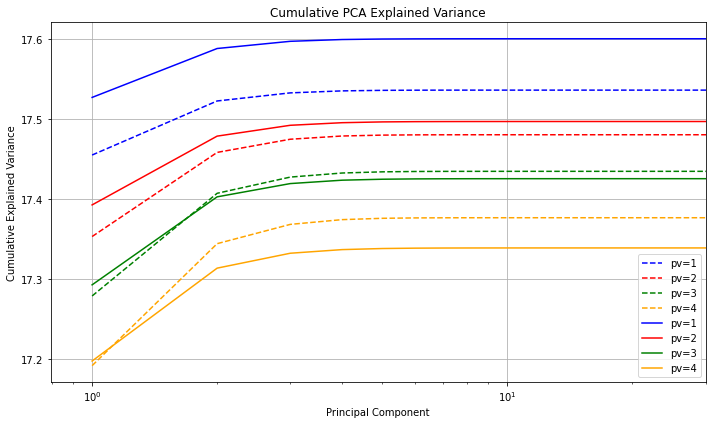

In [ ]:
# Plot cumulative PCA explained variances for multiple pv values
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr0/"
pv_sublist = ["1", "2", "3", "4"]  # Define which pv values to plot
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']  # Color options

# Create single panel plot
plt.figure(figsize=(10, 6))

# Plot PCA for each pv value
for i, pv in enumerate(pv_sublist):
    file = path + pv + "/pca.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        
        # Get the eigenvalues (principal component values)
        pc_values = data['network_data'][0]['result_value']['explained_variance']
        
        # Calculate cumulative sum
        cumsum = np.cumsum(pc_values)
        
        # Plot cumulative explained variance
        plt.plot(range(1, len(cumsum)+1), cumsum, '--', 
                color=colors[i % len(colors)], label=f'pv={pv}')
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/AnalyzedData/ff_scan_pr1/"
# Plot PCA for each pv value
for i, pv in enumerate(pv_sublist):
    file = path + pv + "/pca.pkl"
    try:
        with open(file, "rb") as f:
            data = pickle.load(f)
        
        # Get the eigenvalues (principal component values)
        pc_values = data['network_data'][0]['result_value']['explained_variance']
        
        # Calculate cumulative sum
        cumsum = np.cumsum(pc_values)
        
        # Plot cumulative explained variance
        plt.plot(range(1, len(cumsum)+1), cumsum, '-', 
                color=colors[i % len(colors)], label=f'pv={pv}')
    except FileNotFoundError:
        print(f"File not found for pv={pv}: {file}")
    except Exception as e:
        print(f"Error processing pv={pv}: {e}")

plt.title('Cumulative PCA Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.xscale('log')
#plt.ylim(0,20)
plt.xlim(0,30)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev"

#with open(path + "/" + str(5) + "/SavedData.pkl", "rb") as file:

#file = path + "/" + str(1) + "/0SavedData.pkl"
file = path + "/1_3/SavedData.pkl"
data_logger = NetworkDataLogger(file)

# Access individual networks
if data_logger.network_data:
    first_network = data_logger.get_network_by_index(0)
    print(f"First network has {len(first_network['cycles'])} cycles")

    
    # Access network parameters
    network_params = first_network['network_params']
    print(f"Network has {network_params['n_species']} species and {network_params['n_reactions']} reactions")
    
    # Access conservation changes
    interaction_matrix = first_network['interaction_matrix']
    
    # Access cycles and sign conditions
    cycles = first_network['cycles']
    #print(cycles)
    # sign_conditions = first_network['sign_conditions']

    adjacency_matrix = data_logger.get_network_by_index(0)['adjacency_matrix']
    input_substrates = data_logger.get_network_by_index(0)['input_substrates']
    NR = data_logger.get_network_by_index(0)['NR']
    NS = data_logger.get_network_by_index(0)['NS']

    #visualize_dag_signaling_network(adjacency_matrix, [input_substrates], NR, NS)



Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/1_3/SavedData.pkl
First network has 2 cycles
Network has 7 species and 40 reactions


Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/1_2/SavedData.pkl
Fitting PCA on networks for pv=1_2...
Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/1_3/SavedData.pkl
Fitting PCA on networks for pv=1_3...


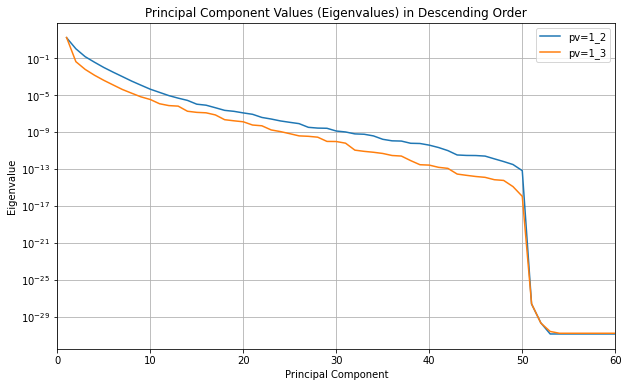

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev"

# Create figure before loop
plt.figure(figsize=(10,6))

pv_list = ["1_2", "1_3"]
for pv in pv_list:
    file = path + "/" + pv + "/SavedData.pkl"
    data_logger = NetworkDataLogger(file)
    #print(count_paths_to_target(data_logger, 0))

    # Fit PCA on the networks
    print(f"Fitting PCA on networks for pv={pv}...")
    pca_result = fit_pca_on_networks(data_logger, n_points=100, target_species_idx=None, n_samples=None, network_indices=None)

    # Get the eigenvalues (principal component values)
    pc_values = pca_result['explained_variance']

    # Plot principal component values in descending order on same axis
    plt.plot(range(1, len(pc_values)+1), pc_values, '-', label=f'pv={pv}')

plt.yscale('log')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue') 
plt.xlim(0,60)
plt.title('Principal Component Values (Eigenvalues) in Descending Order')
plt.grid(True)
plt.legend()
plt.show()

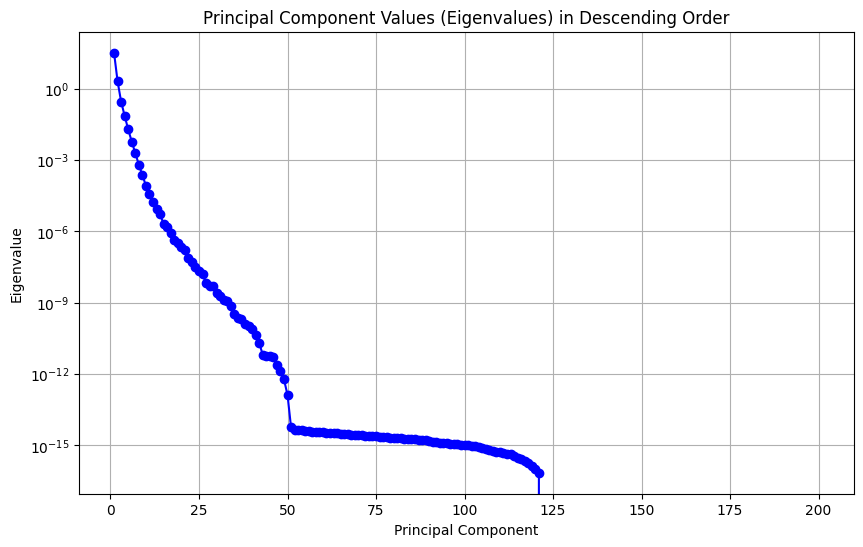

In [ ]:
# Get the eigenvalues (principal component values)
pc_values = pca_result['pca'].explained_variance_

# Plot principal component values in descending order
plt.figure(figsize=(10,6))
plt.plot(range(1, len(pc_values)+1), pc_values, 'bo-')
plt.yscale('log')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Principal Component Values (Eigenvalues) in Descending Order')
plt.grid(True)
plt.show()

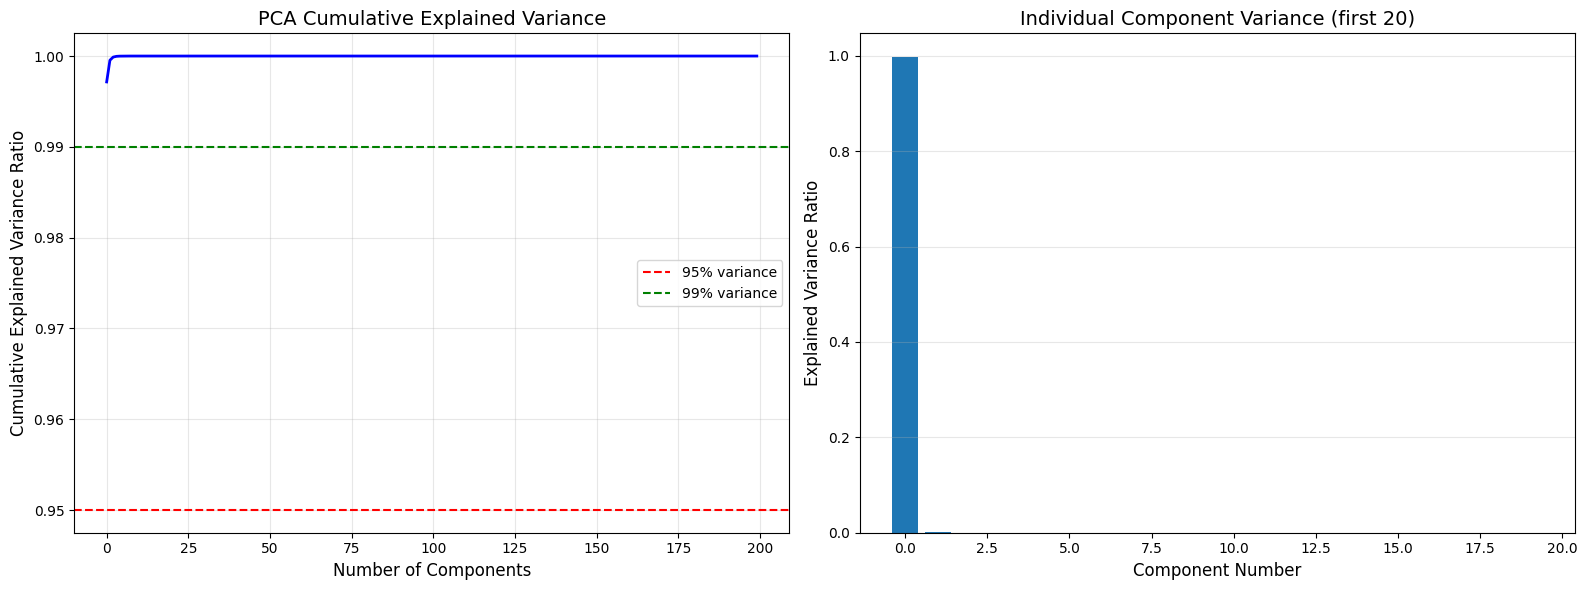


Variance explained by first component: 0.9971
Variance explained by first 2 components: 0.9995
Variance explained by first 5 components: 1.0000
Variance explained by first 10 components: 1.0000


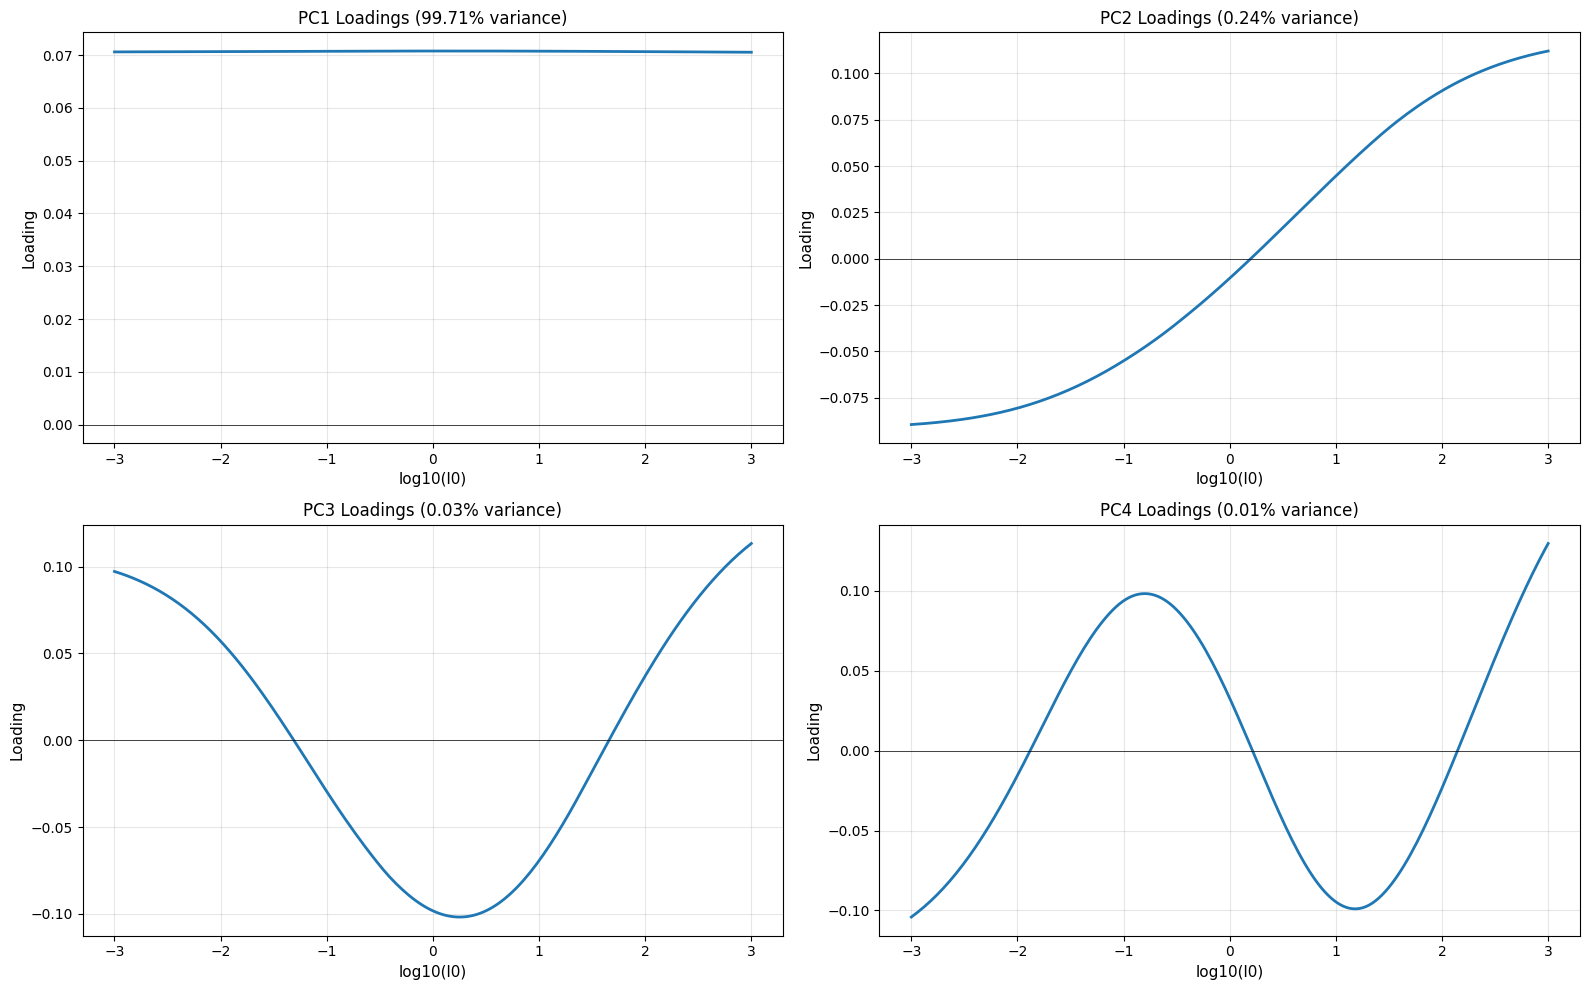

In [ ]:
# Plot 1: Explained variance ratio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative explained variance
ax1 = axes[0]
ax1.plot(np.cumsum(pca_result['explained_variance_']), 'b-', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
ax1.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_title('PCA Cumulative Explained Variance', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Individual explained variance (first 20 components)
ax2 = axes[1]
n_show = min(20, len(pca_result['explained_variance_']))
ax2.bar(range(n_show), pca_result['explained_variance_ratio'][:n_show])
ax2.set_xlabel('Component Number', fontsize=12)
ax2.set_ylabel('Explained Variance Ratio', fontsize=12)
ax2.set_title('Individual Component Variance (first 20)', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print variance statistics
print(f"\nVariance explained by first component: {pca_result['explained_variance_ratio'][0]:.4f}")
print(f"Variance explained by first 2 components: {pca_result['cumulative_variance'][1]:.4f}")
print(f"Variance explained by first 5 components: {pca_result['cumulative_variance'][4]:.4f}")
print(f"Variance explained by first 10 components: {pca_result['cumulative_variance'][9]:.4f}")

# Plot 3: First few principal component loadings (eigenvectors)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

components_to_plot = min(4, pca_result['n_components'])
x_interp = pca_result['x_interp']

for i in range(components_to_plot):
    ax = axes[i]
    # Get the i-th principal component (eigenvector)
    component = pca_result['pca'].components_[i]
    
    ax.plot(x_interp, component, linewidth=2)
    ax.set_xlabel('log10(l0)', fontsize=11)
    ax.set_ylabel('Loading', fontsize=11)
    ax.set_title(f'PC{i+1} Loadings ({pca_result["explained_variance_ratio"][i]:.2%} variance)', 
                 fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

Number of paths from R0 to S2: 4
1.0000448215070052


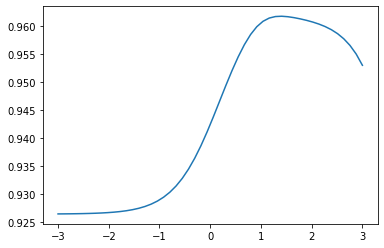

In [ ]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

# List to store number of sign changes for each network
num_sign_changes = []

network_index = 2000
species_names = data_logger.get_network_by_index(network_index)['network_params']['species_names']
l0_list = np.logspace(-3, 3, 50)
log_l0_x = [np.log10(l0[0]) for l0 in data_logger.get_network_by_index(network_index)['l0_list']]

adjacency_matrix = data_logger.get_network_by_index(network_index)['adjacency_matrix']
input_substrates = data_logger.get_network_by_index(network_index)['input_substrates']
NR = data_logger.get_network_by_index(network_index)['NR']
NS = data_logger.get_network_by_index(network_index)['NS']
target_node = 'S'+str(NS-1)
G = get_digraph_from_adjacency_matrix(adjacency_matrix, [input_substrates], NR, NS)
print("Number of paths from R0 to " + target_node + ": " + str(len(count_simple_paths(G, 'R0', target_node))))

interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
        
rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
target_node_idx = species_names.index(target_node)

C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

x_vals = log_l0_x
y_vals = np.array(C_full_list)

plt.plot(x_vals, y_vals)

print(normalized_arc_length(x_vals, y_vals))

100


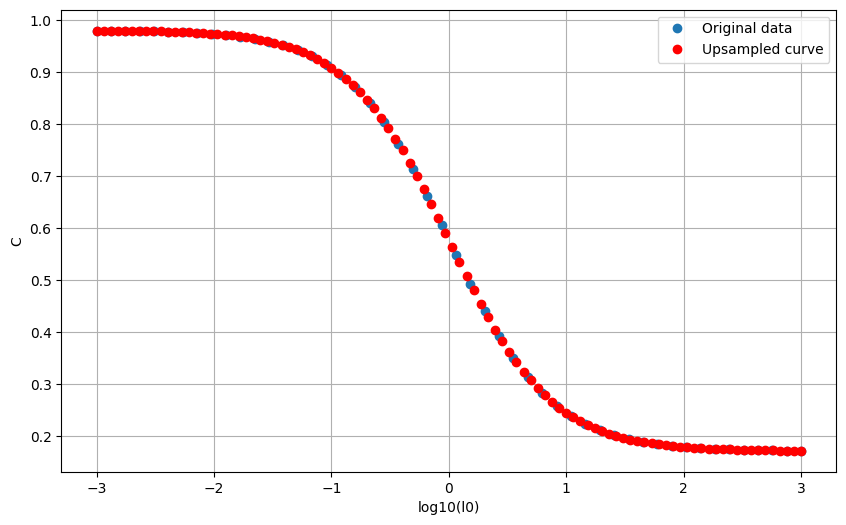

In [ ]:
from scipy.interpolate import CubicSpline

network_index = 0

log_l0_x = [np.log10(l0[0]) for l0 in data_logger.get_network_by_index(network_index)['l0_list']]
C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

# Create cubic spline interpolator
cs = CubicSpline(log_l0_x, C_full_list)

# Generate interpolated points
N_points = 100
x_interp = np.linspace(min(log_l0_x), max(log_l0_x), N_points)
sampled_points = cs(x_interp)
print(len(sampled_points))
# Plot
plt.figure(figsize=(10,6))
plt.plot(log_l0_x, C_full_list, 'o', label='Original data')
plt.plot(x_interp, sampled_points, 'ro', label='Upsampled curve')
plt.xlabel('log10(l0)')
plt.ylabel('C')
plt.legend()
plt.grid(True)
plt.show()

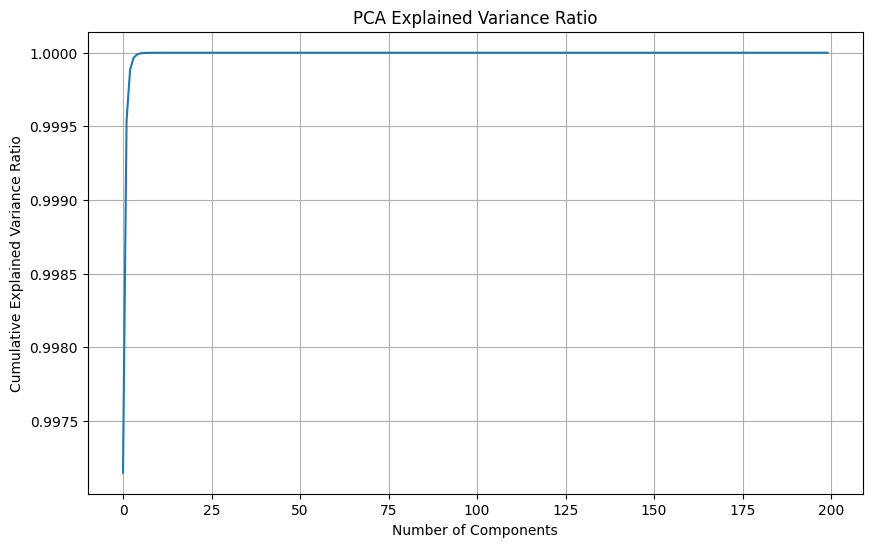

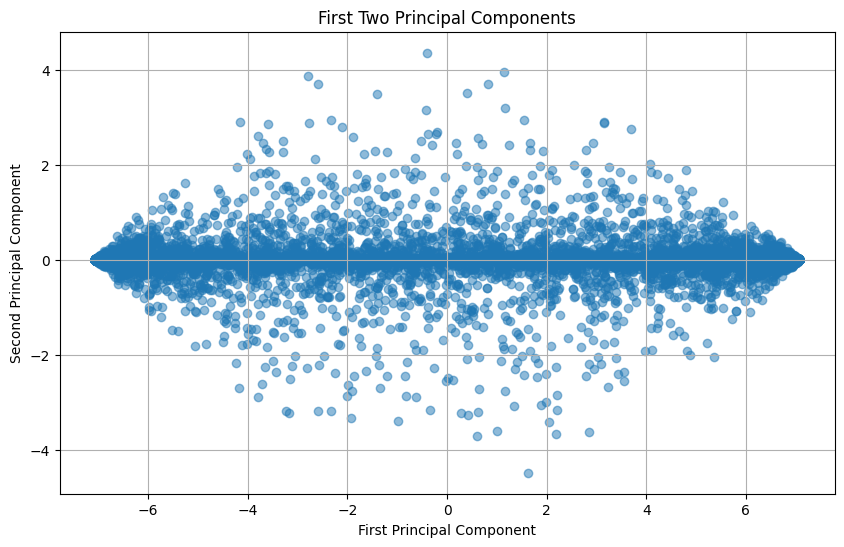

In [ ]:
from scipy.interpolate import CubicSpline
from sklearn.decomposition import PCA

network_index = 0
N_points = 200
N_samples = 25000
data_matrix = np.zeros((N_samples, N_points))

for network_index in range(N_samples):
    log_l0_x = [np.log10(l0[0]) for l0 in data_logger.get_network_by_index(network_index)['l0_list']]
    C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
    cs = CubicSpline(log_l0_x, C_full_list)
    x_interp = np.linspace(min(log_l0_x), max(log_l0_x), N_points)
    sampled_points = cs(x_interp)
    data_matrix[network_index,:] = sampled_points

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(data_matrix)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot explained variance ratio
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.grid(True)
plt.show()

# Plot first two principal components
plt.figure(figsize=(10,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.5)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component') 
plt.title('First Two Principal Components')
plt.grid(True)
plt.show()


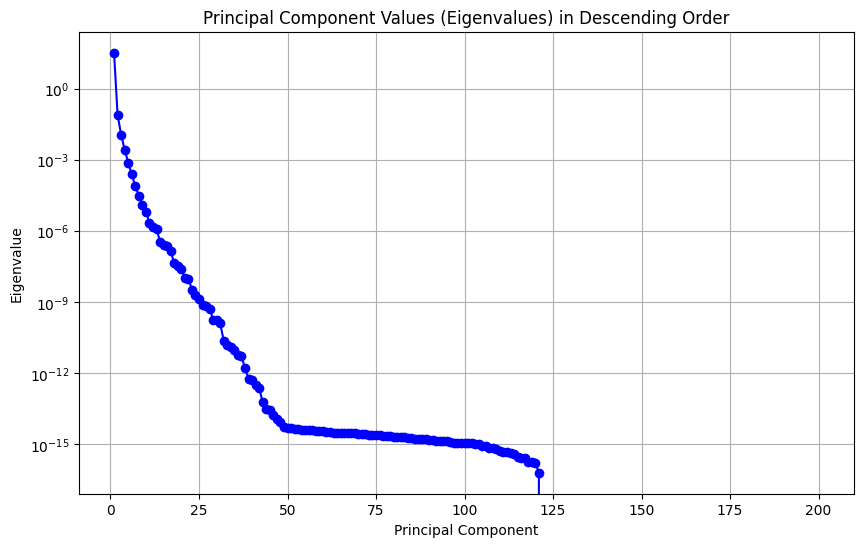

In [ ]:
# Get the eigenvalues (principal component values)
pc_values = pca.explained_variance_

# Plot principal component values in descending order
plt.figure(figsize=(10,6))
plt.plot(range(1, len(pc_values)+1), pc_values, 'bo-')
plt.yscale('log')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Principal Component Values (Eigenvalues) in Descending Order')
plt.grid(True)
plt.show()

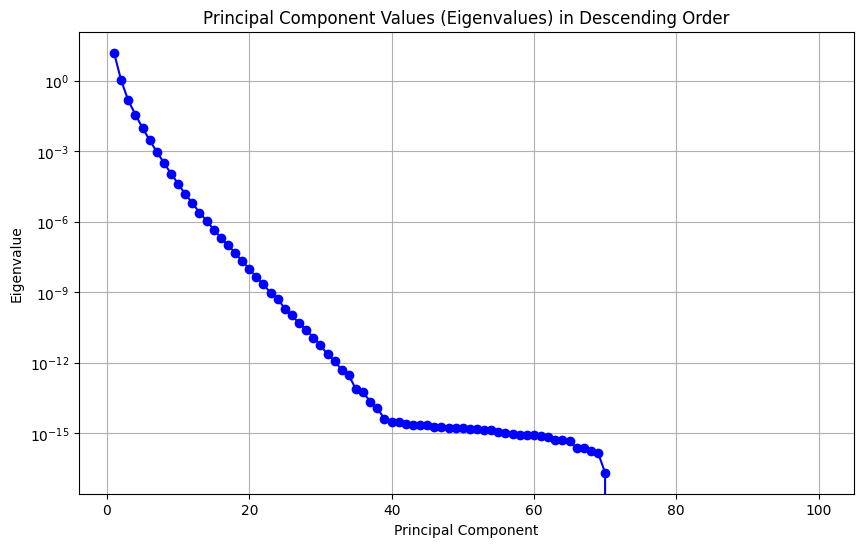

In [ ]:
# Get the eigenvalues (principal component values)
pc_values = pca.explained_variance_

# Plot principal component values in descending order
plt.figure(figsize=(10,6))
plt.plot(range(1, len(pc_values)+1), pc_values, 'bo-')
plt.yscale('log')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Principal Component Values (Eigenvalues) in Descending Order')
plt.grid(True)
plt.show()


In [ ]:
# List to store number of sign changes for each network
num_sign_changes = []

arc_lengths = []
for network_index in range(25000):
    species_names = data_logger.get_network_by_index(network_index)['network_params']['species_names']
    l0_list = np.logspace(-3, 3, 50)
    log_l0_x = [np.log10(l0[0]) for l0 in data_logger.get_network_by_index(network_index)['l0_list']]

    adjacency_matrix = data_logger.get_network_by_index(network_index)['adjacency_matrix']
    input_substrates = data_logger.get_network_by_index(network_index)['input_substrates']
    NR = data_logger.get_network_by_index(network_index)['NR']
    NS = data_logger.get_network_by_index(network_index)['NS']
    target_node = 'S'+str(NS-1)
    G = get_digraph_from_adjacency_matrix(adjacency_matrix, [input_substrates], NR, NS)
    #print("Number of paths from R0 to " + target_node + ": " + str(len(count_simple_paths(G, 'R0', target_node))))

    interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
            
    rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
    target_node_idx = species_names.index(target_node)

    C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

    x_vals = log_l0_x
    y_vals = np.array(C_full_list)
    
    arc_lengths.append(normalized_arc_length(x_vals, y_vals))

arc_lengths = np.array(arc_lengths)

In [ ]:
print(np.max(arc_lengths))
print(np.mean(arc_lengths))
print(np.std(arc_lengths))


1.0326460514344
1.0019408812059798
0.003691034010792348


(array([2.4739e+04, 1.4700e+02, 6.8000e+01, 2.6000e+01, 1.2000e+01,
        2.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00]),
 array([1.        , 1.00199387, 1.00398775, 1.00598162, 1.0079755 ,
        1.00996937, 1.01196324, 1.01395712, 1.01595099, 1.01794487,
        1.01993874]),
 <BarContainer object of 10 artists>)

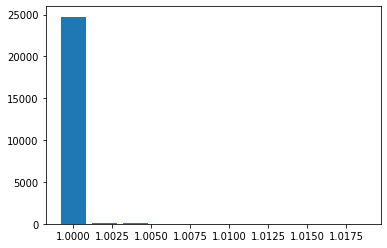

In [ ]:
plt.hist(arc_lengths,  align='left', rwidth=0.8)

In [ ]:
arc_lengths_list = []
for pr in ['0', '0.25', '0.5', '0.75', '1']:
    file = path + "/" + pr + "_2/SavedData.pkl"
    data_logger = NetworkDataLogger(file)
    arc_lengths = []
    for network_index in range(25000):
        species_names = data_logger.get_network_by_index(network_index)['network_params']['species_names']
        l0_list = np.logspace(-3, 3, 50)
        log_l0_x = [np.log10(l0[0]) for l0 in data_logger.get_network_by_index(network_index)['l0_list']]
        C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
        x_vals = log_l0_x
        y_vals = np.array(C_full_list)
        arc_lengths.append(normalized_arc_length(x_vals, y_vals))
    arc_lengths_list.append(arc_lengths)

    

Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/0_2/SavedData.pkl
Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/0.25_2/SavedData.pkl
Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/0.5_2/SavedData.pkl
Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/0.75_2/SavedData.pkl
Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/pr_lhs_NS3_rev/1_2/SavedData.pkl


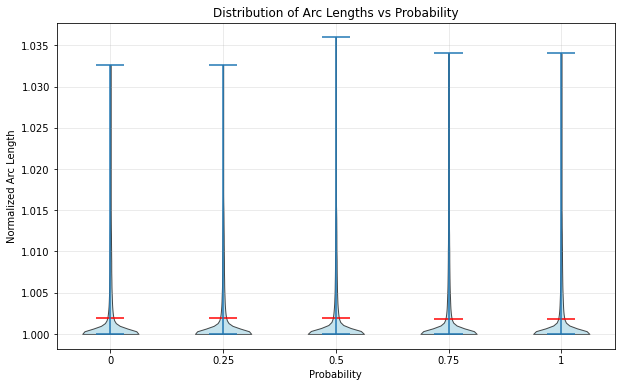

In [ ]:
plt.figure(figsize=(10,6))
violin_parts = plt.violinplot(arc_lengths_list, positions=range(5), showmeans=True)

# Customize violin plot colors
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# Customize mean markers
violin_parts['cmeans'].set_color('red')

plt.xticks(range(5), ['0', '0.25', '0.5', '0.75', '1'])
plt.xlabel('Probability')
plt.ylabel('Normalized Arc Length')
plt.title('Distribution of Arc Lengths vs Probability')
plt.grid(True, alpha=0.3)


In [ ]:
# List to store number of sign changes for each network
num_sign_changes = []

widths = []
for network_index in range(500):
    species_names = data_logger.get_network_by_index(network_index)['network_params']['species_names']
    l0_list = np.logspace(-3, 3, 50)
    log_l0_x = [np.log10(l0[0]) for l0 in data_logger.get_network_by_index(network_index)['l0_list']]

    adjacency_matrix = data_logger.get_network_by_index(network_index)['adjacency_matrix']
    input_substrates = data_logger.get_network_by_index(network_index)['input_substrates']
    NR = data_logger.get_network_by_index(network_index)['NR']
    NS = data_logger.get_network_by_index(network_index)['NS']
    target_node = 'S'+str(NS-1)
    G = get_digraph_from_adjacency_matrix(adjacency_matrix, [input_substrates], NR, NS)
    #print("Number of paths from R0 to " + target_node + ": " + str(len(count_simple_paths(G, 'R0', target_node))))

    interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
            
    rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
    target_node_idx = species_names.index(target_node)

    C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

    x_vals = log_l0_x
    y_vals = np.array(C_full_list)

    result = select_best_mlp_width(x_vals, y_vals, width_range=(2, 6), normalize_x=True, r2_threshold = 0.999, quiet = True)
    widths.append(result['best_width'])

print(np.mean(widths))
print(np.std(widths))
print(np.max(widths))


2.034
0.22987822863420537
4


Number of paths from R0 to S8: 16


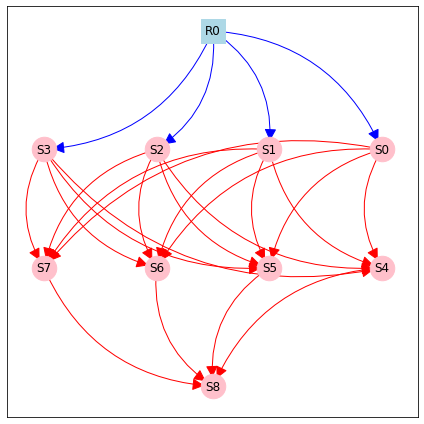

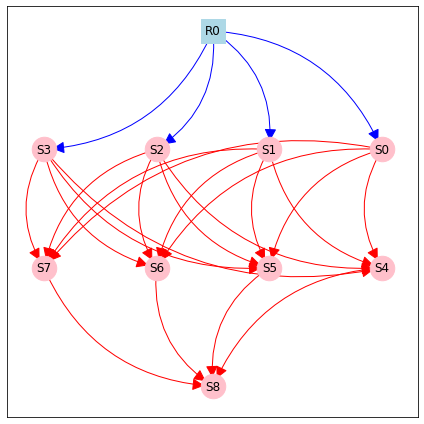

In [ ]:
NR = 1
NS_vec = [4,4,1]
NS = sum(NS_vec)
target_node = 'S'+str(NS-1)
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, 0)
target_node = 'S'+str(NS-1)
target_node_idx = species_names.index(target_node)


G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
print("Number of paths from R0 to " + target_node + ": " + str(len(count_simple_paths(G, 'R0', target_node))))
visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS)

(1, 10000)

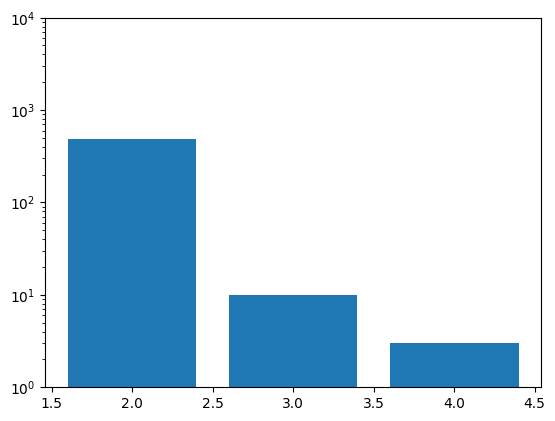

In [ ]:
plt.hist(widths, bins=range(min(widths), max(widths) + 2, 1), align='left', rwidth=0.8)
plt.yscale('log')
plt.ylim(1, 10000)

Scanning MLP widths from 2 to 10...
Width 2: R² = 0.9897, MSE = 0.000000, Params = 7
Width 3: R² = 0.9911, MSE = 0.000000, Params = 10
Width 4: R² = 0.9999, MSE = 0.000000, Params = 13
Width 5: R² = 0.9994, MSE = 0.000000, Params = 16
Width 6: R² = 0.9995, MSE = 0.000000, Params = 19
Width 7: R² = 0.9996, MSE = 0.000000, Params = 22
Width 8: R² = 0.9999, MSE = 0.000000, Params = 25
Width 9: R² = 0.9994, MSE = 0.000000, Params = 28
Width 10: R² = 0.9999, MSE = 0.000000, Params = 31

=== Results Summary ===
R² threshold: 0.999
Best width meeting threshold: 4
Threshold met: True
Number of candidates: 7
Selected best width: 4
Best R²: 0.9999
Best MSE: 0.000000
Number of parameters: 13


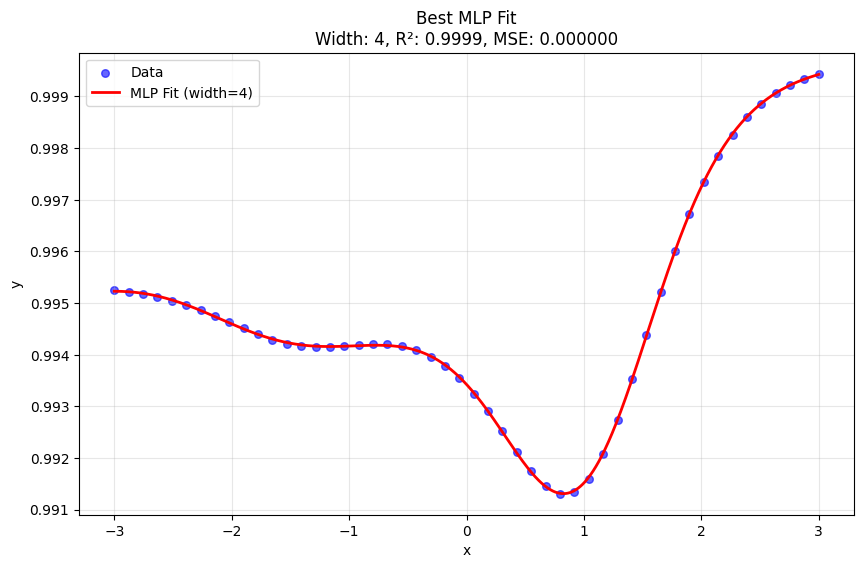

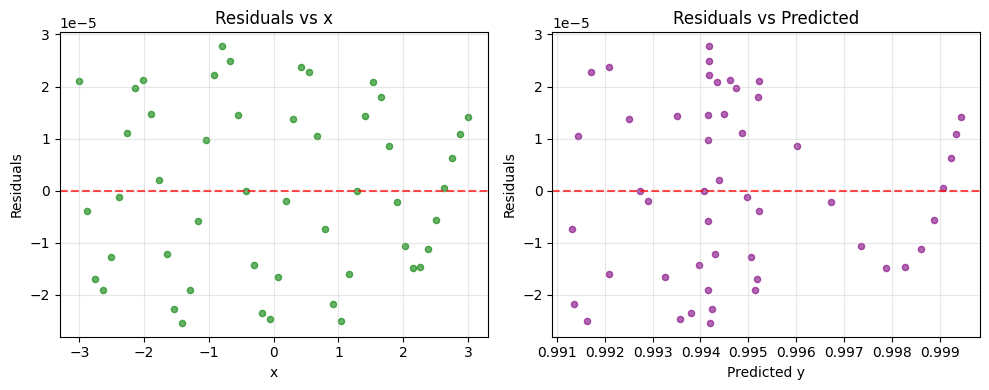


=== All Fits Summary ===
Width  2: R² = 0.9897, MSE = 0.000000, Params =  7
Width  3: R² = 0.9911, MSE = 0.000000, Params = 10
Width  4: R² = 0.9999, MSE = 0.000000, Params = 13
Width  5: R² = 0.9994, MSE = 0.000000, Params = 16
Width  6: R² = 0.9995, MSE = 0.000000, Params = 19
Width  7: R² = 0.9996, MSE = 0.000000, Params = 22
Width  8: R² = 0.9999, MSE = 0.000000, Params = 25
Width  9: R² = 0.9994, MSE = 0.000000, Params = 28
Width 10: R² = 0.9999, MSE = 0.000000, Params = 31


In [ ]:

# Call the function
result = select_best_mlp_width(x_vals, y_vals, width_range=(2, 10), normalize_x=True, r2_threshold = 0.999)

# Extract the best result
best_width = result['best_width']
best_result = result['recommended_result']

print(f"Selected best width: {best_width}")
print(f"Best R²: {best_result['r_squared']:.4f}")
print(f"Best MSE: {best_result['mse']:.6f}")
print(f"Number of parameters: {best_result['n_params']}")

# Plot the best fit
plt.figure(figsize=(10, 6))

# Plot original data
plt.scatter(x_vals, y_vals, alpha=0.6, color='blue', s=30, label='Data')

# Plot fitted curve
x_plot = np.linspace(np.array(x_vals).min(), np.array(x_vals).max(), 1000).reshape(-1, 1)

# Normalize x_plot the same way as training data
if best_result['x_min'] is not None:
    x_plot_norm = (x_plot - best_result['x_min']) / (best_result['x_max'] - best_result['x_min'])
else:
    x_plot_norm = x_plot

# Scale x_plot using the same scaler
x_plot_scaled = best_result['scaler_x'].transform(x_plot_norm)

# Predict on the plot points
y_plot_scaled = best_result['mlp'].predict(x_plot_scaled)
y_plot = best_result['scaler_y'].inverse_transform(y_plot_scaled.reshape(-1, 1)).ravel()

# Plot the fitted curve
plt.plot(x_plot.ravel(), y_plot, 'r-', linewidth=2, label=f'MLP Fit (width={best_width})')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Best MLP Fit\nWidth: {best_width}, R²: {best_result["r_squared"]:.4f}, MSE: {best_result["mse"]:.6f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optional: Plot residuals
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
residuals = np.array(y_vals) - best_result['y_predicted']
plt.scatter(x_vals, residuals, alpha=0.6, color='green', s=20)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Residuals')
plt.title('Residuals vs x')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(best_result['y_predicted'], residuals, alpha=0.6, color='purple', s=20)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Predicted y')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: Show summary of all fits
print("\n=== All Fits Summary ===")
for metric in result['all_metrics']:
    if metric['mse'] != np.inf:
        print(f"Width {metric['width']:2d}: R² = {metric['r_squared']:.4f}, MSE = {metric['mse']:.6f}, Params = {metric['n_params']:2d}")

Number of paths from R0 to S2: 4
0.04666358533671857
0.061022588954724684
Networks [127, 129, 147, 199, 225, 226, 256, 267, 277, 325, 334, 375, 460, 481] have the most sign changes with 2 changes


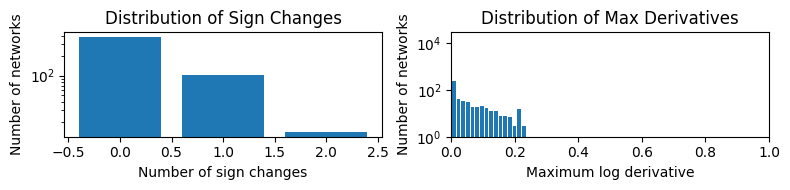

Number of sign changes per network: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 2, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 2, 2, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 

In [ ]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

# List to store number of sign changes for each network
num_sign_changes = []

species_names = data_logger.get_network_by_index(0)['network_params']['species_names']
l0_list = np.logspace(-3, 3, 50)

adjacency_matrix = data_logger.get_network_by_index(0)['adjacency_matrix']
input_substrates = data_logger.get_network_by_index(0)['input_substrates']
NR = data_logger.get_network_by_index(0)['NR']
NS = data_logger.get_network_by_index(0)['NS']
target_node = 'S'+str(NS-1)
G = get_digraph_from_adjacency_matrix(adjacency_matrix, [input_substrates], NR, NS)
print("Number of paths from R0 to " + target_node + ": " + str(len(count_simple_paths(G, 'R0', target_node))))

max_deriv_list = []
# Loop over networks
#for network_index in range(len(data_logger.network_data)):
for network_index in range(500):
    try:
        interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
        
        rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
        target_node_idx = species_names.index(target_node)

        C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
        #l0_list = data_logger.get_network_by_index(network_index)['l0_list']

        # Get d_log_C values and find sign changes
        # d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index)
        # d_vals = [d_log_C_d_log_l0_list[i][target_node_idx][0] for i in range(len(C_full_list))]

        d_C_d_l0_list = data_logger.get_network_by_index(network_index)['dC_dl_list']
        d_vals = d_C_d_l0_list

        # Find indices where sign changes occur
        sign_change_indices = []
        for i in range(len(d_vals)-1):
            if d_vals[i] * d_vals[i+1] < 0:  # Sign change occurs
                sign_change_indices.append(i)
        
        C_vals = C_full_list
        l0_x = [np.log10(l0) for l0 in l0_list]
        #l0_x = [l0 for l0 in l0_list]
        d_vals_fd = calculate_finite_differences(C_vals, l0_x, log_y=False, log_x=True)

        max_log_deriv = np.max(np.abs(d_vals * np.array(l0_list)))
        
        
        if check_list_consistency(d_vals_fd, d_vals, threshold=0.2, pad = 4):
            num_sign_changes.append(len(sign_change_indices))
            max_deriv_list.append(max_log_deriv)
        else:
            print(d_vals_fd)
            print(d_vals)
            print(f"Network {network_index} has inconsistent derivatives")

    except Exception as e:
        print(f"Error processing network {network_index}: {e}")

print(np.mean(max_deriv_list))
print(np.std(max_deriv_list))
# Find index of network with maximum number of sign changes
max_sign_changes = max(num_sign_changes)
max_sign_changes_indices = [i for i, x in enumerate(num_sign_changes) if x == max_sign_changes]
print(f"Networks {max_sign_changes_indices} have the most sign changes with {max_sign_changes} changes")

# Create histograms of sign changes and max derivatives
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2))

# Plot histogram of sign changes
ax1.hist(num_sign_changes, bins=range(min(num_sign_changes), max(num_sign_changes) + 2, 1),
         align='left', rwidth=0.8)
ax1.set_xlabel('Number of sign changes')
ax1.set_ylabel('Number of networks')
ax1.set_title('Distribution of Sign Changes')
ax1.set_yscale('log')

# Plot histogram of max derivatives
ax2.hist(max_deriv_list, bins=20, rwidth=0.8)
ax2.set_xlabel('Maximum log derivative')
ax2.set_ylabel('Number of networks')
ax2.set_title('Distribution of Max Derivatives')
ax2.set_yscale('log')
ax2.set_xlim(0, 1)
ax2.set_ylim(1, 30000)

plt.tight_layout()
plt.show()

print("Number of sign changes per network:", num_sign_changes)

#fig = visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)
print(adjacency_matrix)

In [ ]:
species_names = ['S1s', "S1","S2s","S2"]
int(sum('S' in name for name in species_names) / 2)

2

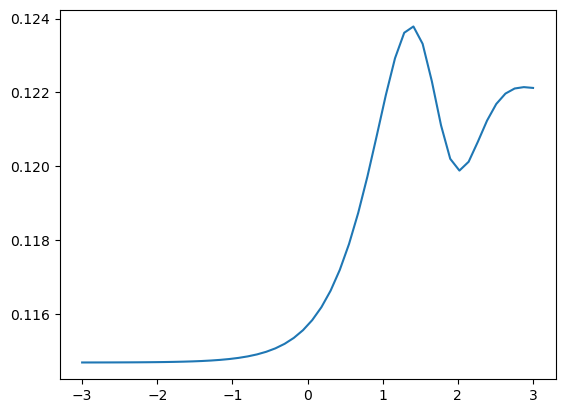

In [ ]:
network_index = 17886
C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

plt.plot(l0_x, C_full_list)

In [ ]:
rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
print(len(rates))

34


In [ ]:
np.log(25000)/np.log(3)

9.217656864304008

In [ ]:
d_C_d_l0_list = data_logger.get_network_by_index(network_index)['dC_dl_list']
print(len(d_C_d_l0_list))

50


In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3_dim_grid_sm"
file = path + "/" + str(0) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)

sign_conditions = data_logger.network_data[0]['sign_conditions']
print(sign_conditions)





Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3_dim_grid_sm/0/SavedData.pkl
[[[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, -1.0], [-1.0, -1.0], [-1.0, -1.0], [1.0, 1.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0]], [[-1.0, 0.0], [-1.0,

In [ ]:
# def get_n_unique_signss(data_logger, cut_off, conservative_comparison = False, log_scale = False, dims = None):
#     n_unique_signs = []
#     for n in range(len(data_logger.network_data)):
#         data = convert_to_log(data_logger, n) if log_scale else data_logger.network_data[n]['dC_dl_list']
#         if dims is not None:
#             rows, cols = dims
#             data = [data[i][np.ix_(rows, cols)] for i in range(len(data))]
#         signs_conditions = get_sign_conditions(data, cut_off)
#         n_unique, tensor_ids = count_unique_tensors_with_ids(signs_conditions, conservative_comparison)
#         n_unique_signs.append(n_unique)
#     return n_unique_signs

# def get_n_unique_signss(data_logger, cut_off, conservative_comparison=False, log_scale=False, dims=None):
#     n_unique_signs = []
    
#     # Pre-allocate data processing
#     if log_scale:
#         data_list = [convert_to_log(data_logger, n) for n in range(len(data_logger.network_data))]
#     else:
#         data_list = [data_logger.network_data[n]['dC_dl_list'] for n in range(len(data_logger.network_data))]
    
#     # Apply dimension filtering once if needed
#     if dims is not None:
#         rows, cols = dims
#         data_list = [[data[i][np.ix_(rows, cols)] for i in range(len(data))] for data in data_list]
    
#     # Process all data in parallel if possible
#     for data in data_list:
#         signs_conditions = get_sign_conditions(data, cut_off)
#         n_unique, tensor_ids = count_unique_tensors_with_ids(signs_conditions, conservative_comparison)
#         n_unique_signs.append(n_unique)
    
#     return n_unique_signs

# def get_n_unique_signs_index(index, data_logger, cut_off, conservative_comparison = False, log_scale = False, dims = None):
#     data = convert_to_log(data_logger, index) if log_scale else data_logger.network_data[index]['dC_dl_list']
#     if dims is not None:
#         rows, cols = dims
#         data = [data[i][np.ix_(rows, cols)] for i in range(len(data))]
#     signs_conditions = get_sign_conditions(data, cut_off)
#     n_unique, tensor_ids = count_unique_tensors_with_ids(signs_conditions, conservative_comparison)
#     return n_unique, tensor_ids

sc_grad_dims = [[6,7,8,9],[0,1]]
n_unique_signs = get_n_unique_signs(data_logger, 1e-6, conservative_comparison = True, log_scale = False, dims = sc_grad_dims)

#n_unique, tensor_ids = get_n_unique_signs_index(202, data_logger, 1e-8, conservative_comparison = True, log_scale = False, dims = sc_grad_dims)



Text(0, 0.5, 'Number of sign conditions')

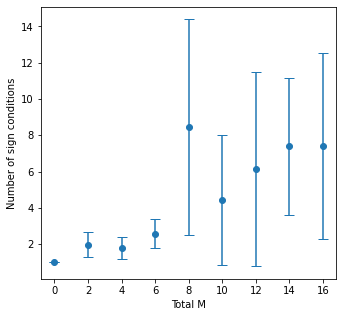

In [ ]:
y_data = np.array([data_logger.network_data[m]['n_sign_conditions'] for m in range(len(data_logger.network_data))])
#y_data = np.array(y_data)
#y_data = np.array(n_unique_signs)
#M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
#M_values = np.array([data_logger.network_data[n]['interaction_matrix'].sum() for n in range(len(data_logger.network_data))])
#M_values = np.array([np.triu(data_logger.network_data[n]['interaction_matrix']).sum() for n in range(len(data_logger.network_data))])
M_values = np.array([np.triu(data_logger.network_data[n]['interaction_matrix']).sum() for n in range(len(data_logger.network_data))])

unique_M = np.unique(M_values)
n_sign_conditions_by_M = {M: y_data[M_values == M].tolist() for M in unique_M}
means = [np.mean(n_sign_conditions_by_M[M]) for M in unique_M]
stds = [np.std(n_sign_conditions_by_M[M]) for M in unique_M]
medians = [np.median(n_sign_conditions_by_M[M]) for M in unique_M]
mads = [np.median(np.abs(np.array(n_sign_conditions_by_M[M]) - np.median(n_sign_conditions_by_M[M]))) for M in unique_M]



plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.errorbar(unique_M, means, yerr=stds, fmt='o', capsize=5)
#plt.errorbar(unique_M, medians, yerr=mads, fmt='o', capsize=5)
plt.xlabel('Total M')
plt.ylabel('Number of sign conditions')
#plt.ylim(0,12)

# plt.subplot(1,3,2)
# plt.boxplot([y_data[M_values == M] for M in unique_M], positions=unique_M)
# plt.xlabel('Total M')
# plt.ylabel('Number of sign conditions')
# #plt.ylim(0,12)

# plt.subplot(1,3,3)
# samples_per_M = [np.sum(M_values == M) for M in unique_M]
# plt.bar(unique_M, samples_per_M)
# plt.yscale('log')
# plt.xlabel('Total M')
# plt.ylabel('Number of samples')

In [ ]:
print(np.mean(n_sign_conditions_by_M[16]))

2.25


In [ ]:
inds_by_M = {M: np.where(M_values == M)[0].tolist() for M in unique_M}
ys_by_M = {M: y_data[inds_by_M[M]] for M in unique_M}

M=12
l= [(ys_by_M[M][t], inds_by_M[M][t]) for t in range(len(ys_by_M[M]))]

sorted_list = sorted(l, key=lambda x: x[0], reverse=True)
print(sorted_list)
print("")


[(30, 826), (25, 706), (24, 11), (23, 209), (22, 897), (21, 321), (21, 839), (20, 2251), (19, 2068), (18, 403), (18, 2390), (18, 2459), (17, 2440), (16, 366), (16, 795), (16, 1192), (16, 2263), (15, 1202), (15, 1451), (15, 2323), (14, 197), (14, 1654), (13, 652), (13, 766), (12, 164), (12, 398), (12, 1089), (12, 1595), (12, 2062), (12, 2315), (11, 128), (11, 990), (11, 1040), (11, 1161), (11, 1308), (11, 1856), (11, 2116), (10, 60), (10, 269), (10, 484), (10, 491), (10, 529), (10, 579), (10, 731), (10, 1582), (10, 2152), (10, 2218), (9, 206), (9, 244), (9, 261), (9, 283), (9, 477), (9, 1029), (9, 1108), (9, 2112), (8, 340), (8, 1077), (8, 1893), (8, 1978), (8, 1988), (7, 264), (7, 369), (7, 868), (7, 2389), (6, 0), (6, 136), (6, 1329), (6, 1537), (5, 1346), (5, 1602), (5, 1608), (5, 2205), (4, 20), (4, 326), (4, 389), (4, 500), (4, 541), (4, 862), (4, 1227), (4, 1358), (4, 1396), (4, 1532), (4, 1665), (4, 1711), (4, 1768), (4, 1790), (4, 1972), (4, 1991), (4, 2013), (4, 2028), (4, 2050

In [ ]:
data_logger.network_data[network_index].keys()

dict_keys(['network_params', 'interaction_matrix', 'cycles', 'n_cycles', 'sign_conditions', 'n_sign_conditions', 'C_full_list', 'l0_list', 'iteration', 'seed', 'dC_dl_list', 'E_range', 'B_range', 'F_range', 'C0', 'beta', 'sample_count', 'convergence_reached'])

12.0
30
5


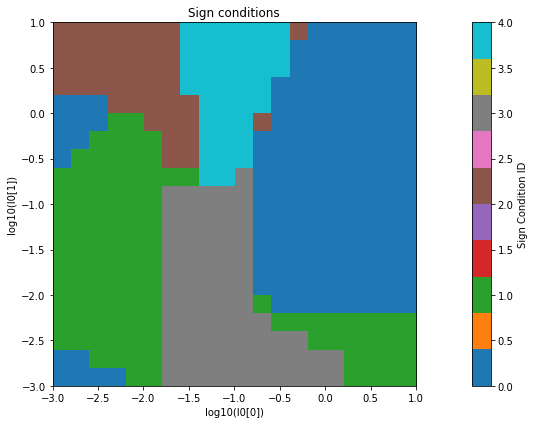

In [ ]:
network_index = 826

print(M_values[network_index])
print(data_logger.network_data[network_index]['n_sign_conditions'])


C_ind = 6
l_ind = 1
l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])  
l0_y = np.array([l0[1] for l0 in l0_list])  
d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index)
dC_dl_data = data_logger.network_data[network_index]['dC_dl_list']

#C_data = [C_full_list[i][C_ind]  for i in range(len(C_full_list))]
#C_data = [np.log10(C_full_list[i][C_ind])  for i in range(len(C_full_list))]
C_data = [C_full_list[i][C_ind]  for i in range(len(C_full_list))]
#C_data = [dC_dl_data[i][C_ind][l_ind]  for i in range(len(dC_dl_data))]
C_data = [d_log_C_d_log_l0_list[i][C_ind][l_ind]  for i in range(len(C_full_list))]


cut = 1e-8

#sign_condition_ids = get_sign_condition_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list])
#n_conds, sign_condition_ids = count_unique_tensors_with_ids([clamp_sign(p, cut).tolist() for p in d_log_C_d_log_l0_list], conservative_comparison = True)#, log_scale = False)

n_conds, sign_condition_ids = get_n_unique_signs_index(network_index, data_logger, 1e-6, conservative_comparison = True, log_scale = False, dims = sc_grad_dims)
print(n_conds)

# Create figure with two subplots side by side
fig, (ax) = plt.subplots(1, 1, figsize=(16,6))

p_vals = C_data
#p_vals = [clamp_sign(p, cut) for p in p_vals]
cmap = 'viridis'

p_vals = sign_condition_ids
cmap = 'tab10'

# Reshape sign_condition_ids into a 2D array
n = int(np.sqrt(len(p_vals)))  # Assuming square grid
p_values = np.array(p_vals).reshape(n, n).T

# Plot using imshow
im = ax.imshow(p_values, origin='lower', aspect='auto',
                extent=[np.log10(l0_x.min()), np.log10(l0_x.max()),
                        np.log10(l0_y.min()), np.log10(l0_y.max())],
                cmap=cmap)

ax.set_xlabel('log10(l0[0])')
ax.set_ylabel('log10(l0[1])')
ax.set_title('Sign conditions')
ax.set_aspect(1)

fig.colorbar(im, ax=ax, label='Sign Condition ID')

plt.tight_layout()
plt.show()

In [ ]:
dC_dl_data[20]

array([[  -0.49997529,    0.        ,    0.        ],
       [   0.55395593,   -0.        ,   -0.        ],
       [   0.44599464,   -0.        ,   -0.        ],
       [   0.        ,   -0.49994516,    0.        ],
       [  -0.        ,    0.80652617,   -0.        ],
       [  -0.        ,    0.19336414,   -0.        ],
       [ -32.98130776,    0.        ,   -0.82026114],
       [ 100.30359157,   -0.        ,    0.19353493],
       [-137.83158946,   -0.        ,    0.23573331],
       [  70.50930565,   -0.        ,    0.3909929 ]])

In [ ]:
data_logger.network_data[network_index]['interaction_matrix']

array([[0., 0., 6.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
inds_by_M = {M: np.where(M_values == M)[0].tolist() for M in unique_M}
ys_by_M = {M: y_data[inds_by_M[M]] for M in unique_M}

M=12
l= [(ys_by_M[M][t], inds_by_M[M][t]) for t in range(len(ys_by_M[M]))]

sorted_list = sorted(l, key=lambda x: x[0], reverse=True)
print(sorted_list)
print("")

[(8, 489), (6, 271), (6, 456), (5, 268), (4, 71), (4, 151), (4, 468), (4, 475), (3, 43), (3, 211), (3, 355), (3, 484), (2, 8), (2, 10), (2, 26), (2, 30), (2, 34), (2, 36), (2, 115), (2, 249), (2, 279), (2, 311), (2, 349), (2, 352), (2, 353), (2, 359), (2, 400), (2, 412), (2, 430), (2, 439), (2, 445), (2, 449), (2, 498), (1, 44), (1, 63), (1, 68), (1, 81), (1, 97), (1, 137), (1, 139), (1, 150), (1, 154), (1, 187), (1, 196), (1, 200), (1, 204), (1, 228), (1, 232), (1, 235), (1, 240), (1, 253), (1, 255), (1, 274), (1, 332), (1, 341), (1, 370), (1, 407), (1, 413), (1, 420), (1, 452), (1, 483)]



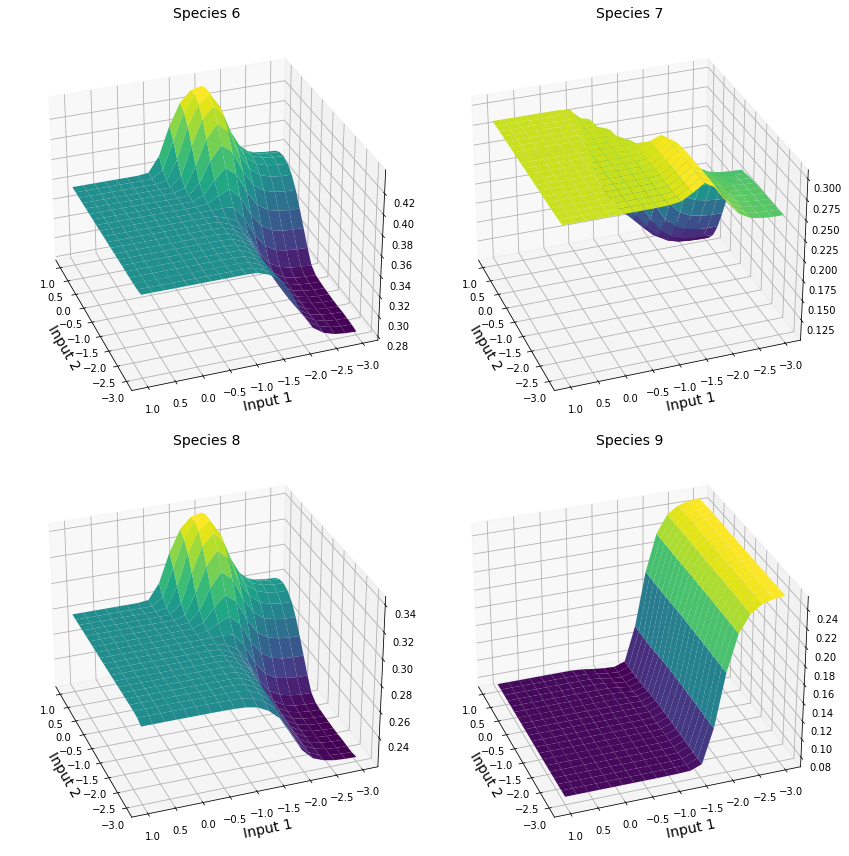

In [ ]:
from scipy.interpolate import griddata
from matplotlib import cm

network_index = 826

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(12,12))

for i, C_ind in enumerate([6,7,8,9]):
    # Get log concentrations for this species
    # C_data = [np.log10(C_full_list[i][C_ind]) for j in range(len(C_full_list))]
    C_data = [C_full_list[j][C_ind] for j in range(len(C_full_list))]
    
    # Create 3D subplot in 2x2 grid
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    

    # Take the log of the coordinates
    log_X = np.log10(X)
    log_Y = np.log10(Y)

    # Create finer interpolation grid in log space
    # Determine the range of your log-transformed data
    log_x_min, log_x_max = log_X.min(), log_X.max()
    log_y_min, log_y_max = log_Y.min(), log_Y.max()

    # Create finer grid (adjust the number of points as needed)
    n_points_x = 20  # Increase this for finer interpolation
    n_points_y = 20

    # Generate uniform linear-spaced points in log space
    log_x_fine = np.linspace(log_x_min, log_x_max, n_points_x)
    log_y_fine = np.linspace(log_y_min, log_y_max, n_points_y)

    # Create the fine meshgrid
    log_X_fine, log_Y_fine = np.meshgrid(log_x_fine, log_y_fine)

    # Prepare data for interpolation
    # Flatten the log-transformed data points
    points = np.column_stack((log_X.ravel(), log_Y.ravel()))
    values = Z.ravel()

    # Do linear interpolation on the log-transformed data
    Z_fine = griddata(points, values, (log_X_fine, log_Y_fine), method='linear')
    #my_col = cm.jet(Z_fine/np.amax(Z_fine))

    # Plot the interpolated surface
    surf = ax.plot_surface(log_X_fine, log_Y_fine, Z_fine,  cmap='viridis')

    # Set viewpoint 
    ax.view_init(elev=30, azim=160)
    
    fs = 14
    ax.set_facecolor('white')
    ax.set_xlabel('Input 2', fontsize=fs)
    ax.set_ylabel('Input 1', fontsize=fs)
    #ax.set_zlabel('C', fontsize=fs)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    #ax.set_zlim(0, 1)
    ax.set_title(f'Species {C_ind}', fontsize=fs)
    
    # Add colorbar
    #fig.colorbar(surf, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

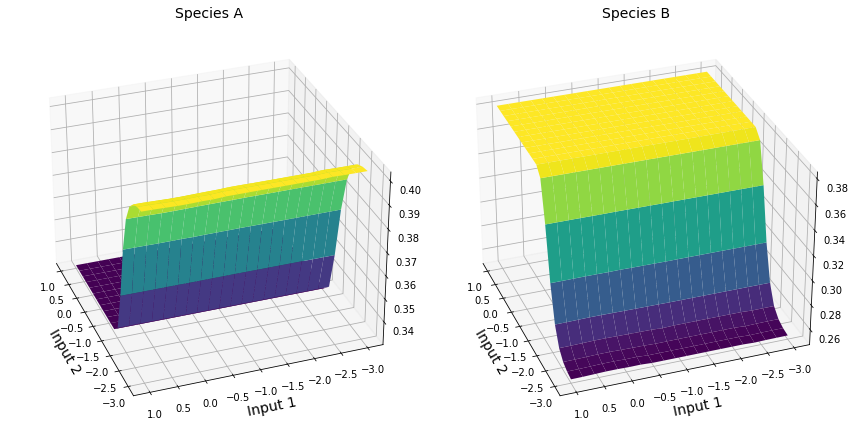

In [ ]:
from scipy.interpolate import griddata
from matplotlib import cm

network_index = 13

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(12,6))

names = ["A","B"]
for i, C_ind in enumerate([6,7]):
    # Get log concentrations for this species
    # C_data = [np.log10(C_full_list[i][C_ind]) for j in range(len(C_full_list))]
    C_data = [C_full_list[j][C_ind] for j in range(len(C_full_list))]
    
    # Create 3D subplot in 2x2 grid
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    

    # Take the log of the coordinates
    log_X = np.log10(X)
    log_Y = np.log10(Y)

    # Create finer interpolation grid in log space
    # Determine the range of your log-transformed data
    log_x_min, log_x_max = log_X.min(), log_X.max()
    log_y_min, log_y_max = log_Y.min(), log_Y.max()

    # Create finer grid (adjust the number of points as needed)
    n_points_x = 20  # Increase this for finer interpolation
    n_points_y = 20

    # Generate uniform linear-spaced points in log space
    log_x_fine = np.linspace(log_x_min, log_x_max, n_points_x)
    log_y_fine = np.linspace(log_y_min, log_y_max, n_points_y)

    # Create the fine meshgrid
    log_X_fine, log_Y_fine = np.meshgrid(log_x_fine, log_y_fine)

    # Prepare data for interpolation
    # Flatten the log-transformed data points
    points = np.column_stack((log_X.ravel(), log_Y.ravel()))
    values = Z.ravel()

    # Do linear interpolation on the log-transformed data
    Z_fine = griddata(points, values, (log_X_fine, log_Y_fine), method='linear')
    #my_col = cm.jet(Z_fine/np.amax(Z_fine))

    # Plot the interpolated surface
    surf = ax.plot_surface(log_X_fine, log_Y_fine, Z_fine,  cmap='viridis')

    # Set viewpoint 
    ax.view_init(elev=30, azim=160)
    
    fs = 14
    ax.set_facecolor('white')
    ax.set_xlabel('Input 2', fontsize=fs)
    ax.set_ylabel('Input 1', fontsize=fs)
    #ax.set_zlabel('C', fontsize=fs)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    #ax.set_zlim(0, 1)
    ax.set_title(f'Species {names[i]}', fontsize=fs)
    
    # Add colorbar
    #fig.colorbar(surf, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

In [ ]:
[C_full_list[j][6] for j in range(len(C_full_list))]

[0.5502897146170401,
 0.5502897146170402,
 0.5502897146170401,
 0.5502897146170402,
 0.5502897146170417,
 0.55028971461706,
 0.5502897146170407,
 0.5502897146170402,
 0.5502897146170401,
 0.550289714617041,
 0.55028971461704,
 0.5502897146170398,
 0.5502897146170402,
 0.5502897146170401,
 0.5502897146170402,
 0.5502897146170406,
 0.5502897146170406,
 0.5502897146170402,
 0.5502897146170399,
 0.5502897146170402,
 0.5502897146158052,
 0.5502897146170402,
 0.5502897146170403,
 0.5502897146170401,
 0.5502897146170397,
 0.5502897146170401,
 0.5502897146170405,
 0.5502897146170405,
 0.5502897146170709,
 0.55028971461704,
 0.55028971461704,
 0.5502897146170402,
 0.5502897146170402,
 0.55028971461704,
 0.55028971461704,
 0.5502897146170448,
 0.5502897146170406,
 0.5502897146170401,
 0.5502897146170421,
 0.5502897146170378,
 0.5502897146170398,
 0.55028971461704,
 0.55028971461704,
 0.5502897146170403,
 0.5502897146170399,
 0.55028971461704,
 0.5502897146170401,
 0.5502897146170397,
 0.55028971

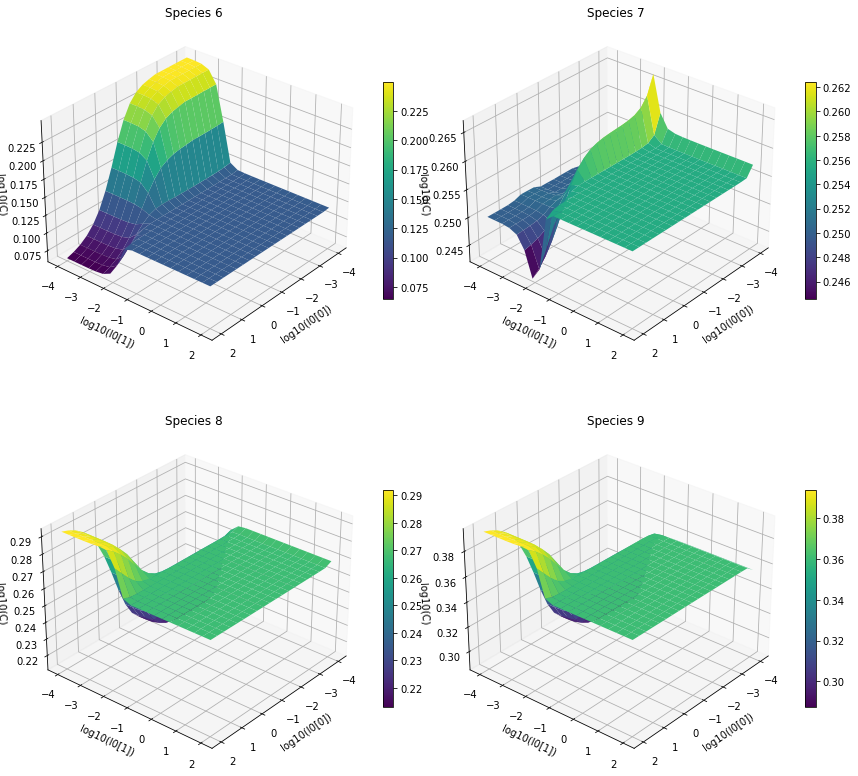

In [ ]:
network_index = 1987

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(12,12))

for i, C_ind in enumerate([6,7,8,9]):
    # Get log concentrations for this species
    C_data = [np.log10(C_full_list[i][C_ind]) for i in range(len(C_full_list))]
    C_data = [C_full_list[i][C_ind] for i in range(len(C_full_list))]
    
    # Create 3D subplot in 2x2 grid
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    
    # Plot surface
    surf = ax.plot_surface(np.log10(X), np.log10(Y), Z, cmap='viridis')
    
    # Set viewpoint 
    ax.view_init(elev=30, azim=40)
    
    ax.set_xlabel('log10(l0[0])')
    ax.set_ylabel('log10(l0[1])')
    ax.set_zlabel('log10(C)')
    ax.set_title(f'Species {C_ind}')
    
    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

In [ ]:
5 * 13849.73 / 3600

19.23573611111111

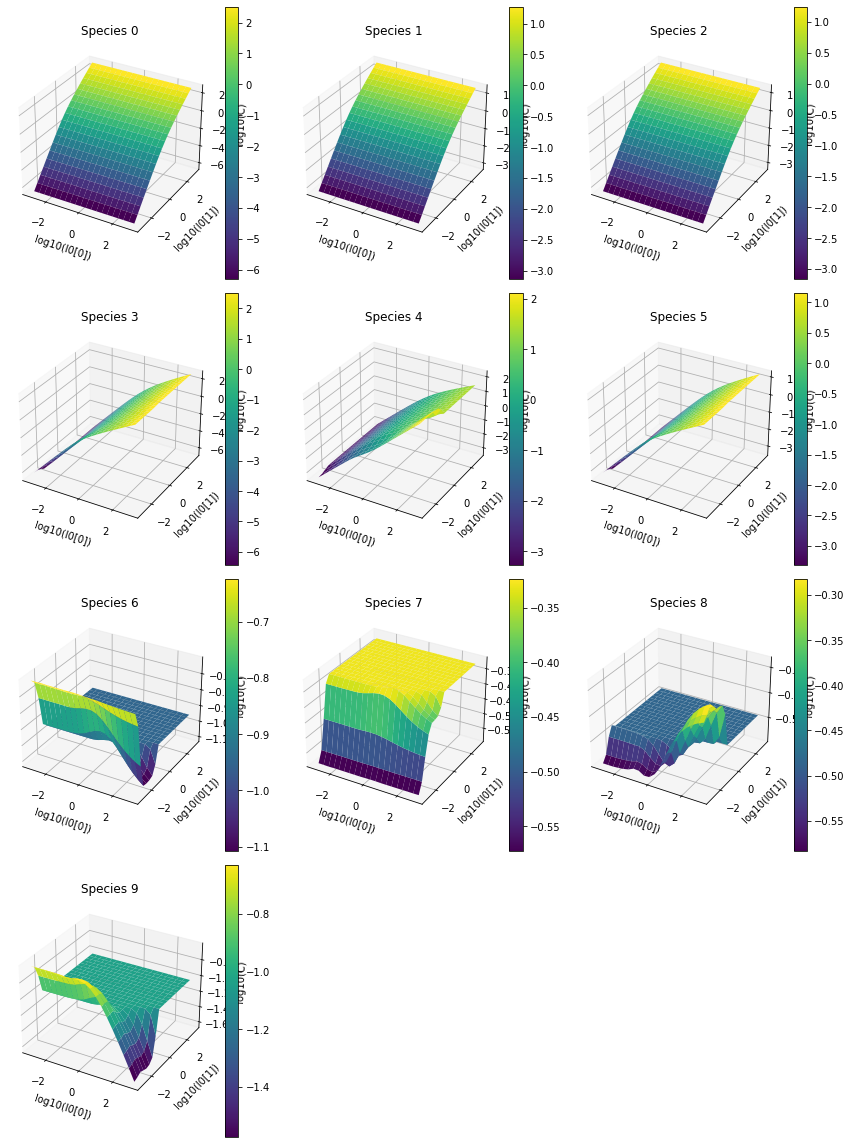

In [ ]:
network_index = 287

l0_list = data_logger.network_data[network_index]['l0_list']
C_full_list = data_logger.network_data[network_index]['C_full_list']

l0_x = np.array([l0[0] for l0 in l0_list])
l0_y = np.array([l0[1] for l0 in l0_list])

# Get number of species from first C_full entry
n_species = C_full_list[0].shape[0]

# Calculate number of rows/cols needed for subplots
n_rows = int(np.ceil(np.sqrt(n_species)))
n_cols = int(np.ceil(n_species / n_rows))

# Create 3D figure with subplots
fig = plt.figure(figsize=(4*n_cols, 4*n_rows))

for C_ind in range(n_species):
    # Get log concentrations for this species
    C_data = [np.log10(C_full_list[i][C_ind]) for i in range(len(C_full_list))]
    
    # Create 3D subplot
    ax = fig.add_subplot(n_rows, n_cols, C_ind+1, projection='3d')
    
    # Create meshgrid for 3D surface
    X, Y = np.meshgrid(np.unique(l0_x), np.unique(l0_y))
    Z = np.array(C_data).reshape(X.shape)
    
    # Plot surface
    surf = ax.plot_surface(np.log10(X), np.log10(Y), Z, cmap='viridis')
    
    ax.set_xlabel('log10(l0[0])')
    ax.set_ylabel('log10(l0[1])')
    ax.set_zlabel('log10(C)')
    ax.set_title(f'Species {C_ind}')
    
    # Add colorbar
    fig.colorbar(surf, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
data_logger.get_network_by_index(10).keys()


dict_keys(['network_params', 'conservation_changes', 'cycles', 'n_cycles', 'sign_conditions', 'n_sign_conditions', 'C_full_list', 'l0_list', 'iteration', 'seed', 'dC_dl_list', 'E_range', 'B_range', 'F_range', 'C0', 'beta', 'sample_count', 'convergence_reached'])

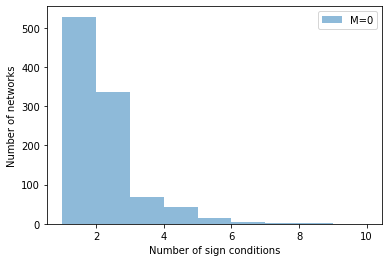

In [ ]:
plt.hist(n_unique_signs, bins=range(1, 11), alpha=0.5)
plt.xlabel('Number of sign conditions')
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
plt.yscale('log')
plt.show()

In [ ]:
print(type(np.array(n_unique_signs)))

<class 'numpy.ndarray'>


Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range/5/SavedData.pkl
2.269230769230769


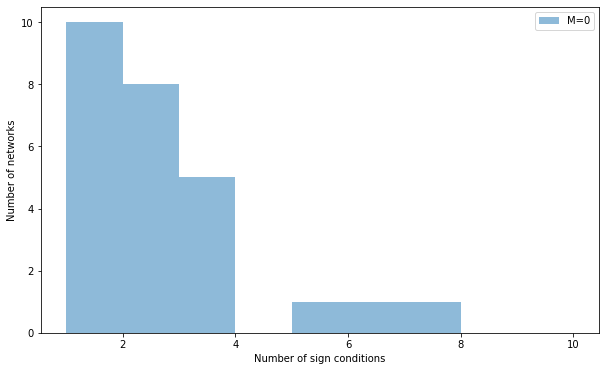

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range"
file = path + "/" + str(4) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])
y_data = np.array(n_unique_signs)

# Group n_sign_conditions by M values
unique_M = np.unique(M_values)

n_sign_conditions_by_M = {M: y_data[M_values == M].tolist() for M in unique_M}


M = 8
print(np.mean(n_sign_conditions_by_M[M]))
plt.figure(figsize=(10,6))
plt.hist(n_sign_conditions_by_M[M], bins=range(1, 11), alpha=0.5)
plt.xlabel('Number of sign conditions')
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
#plt.xlim(0,60)
plt.show()

Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range/5/SavedData.pkl
1.3893376413570275


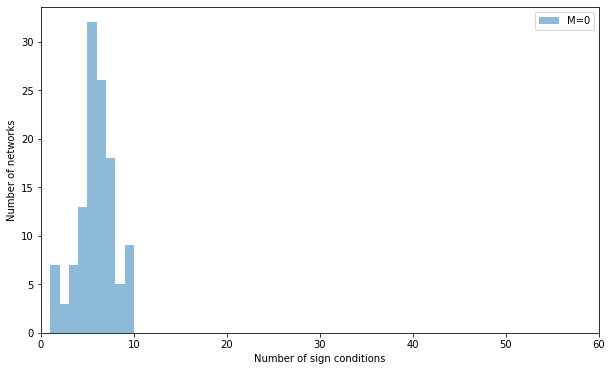

In [ ]:

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range"
file = path + "/" + str(5) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

# Group n_sign_conditions by M values
unique_M = np.unique(M_values)
n_sign_conditions_by_M = {M: n_sign_conditions[M_values == M].tolist() for M in unique_M}
n_sign_conditions_by_M[0]

print(np.mean(n_sign_conditions_by_M[0]))
plt.figure(figsize=(10,6))
plt.hist(n_sign_conditions_by_M[6], bins=range(1, 11), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[2], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[4], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[6], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[8], bins=range(1, 150, 10), alpha=0.5)
# plt.hist(n_sign_conditions_by_M[10], bins=range(1, 150, 10), alpha=0.5)
plt.xlabel('Number of sign conditions')
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
plt.xlim(0,60)
plt.show()


In [ ]:
6916.38 / 3600

1.9212166666666668

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3"

vars = [0, 1, 2, 4]
M_list = []


file = path + "/" + str(0) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)
M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions, inner = "point")
plt.xlabel('Total M')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3/0/SavedData.pkl'

Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3/4/SavedData.pkl


Text(0.5, 0, 'Total M')

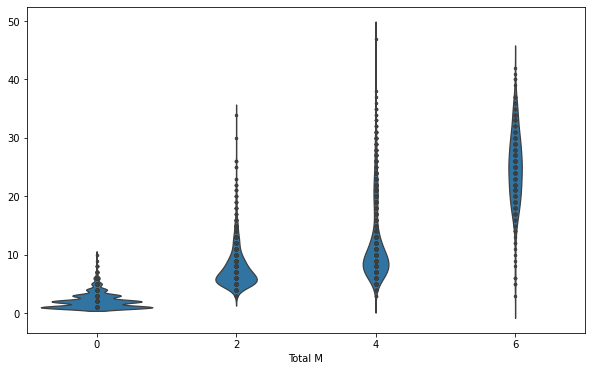

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_3"

vars = [0, 1, 2, 4, 5]
M_list = []


file = path + "/" + str(4) + "/SavedData.pkl"
data_logger = NetworkDataLogger(file)
M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions, inner = "point")
plt.xlabel('Total M')

Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2/5/SavedData.pkl
Data loaded from /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2/0/SavedData.pkl
23.694444444444443
22.390243902439025


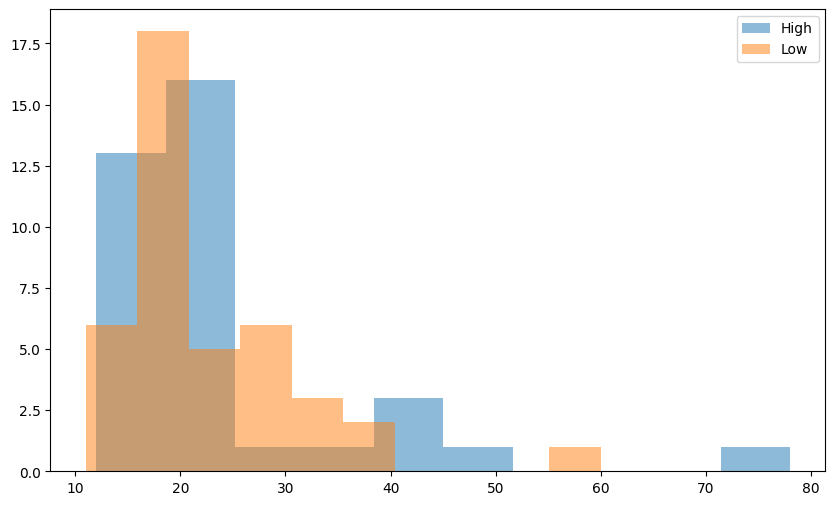

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2"
file = path + "/" + str(5) + "/SavedData.pkl"
data_logger_high = NetworkDataLogger(file)

M_values_high = np.array([data_logger_high.network_data[n]['conservation_changes']['M_0t1'] + data_logger_high.network_data[n]['conservation_changes']['M_1t0'] + data_logger_high.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger_high.network_data))])
n_sign_conditions_high = np.array([data_logger_high.network_data[n]['n_sign_conditions'] for n in range(len(data_logger_high.network_data))])

# Group n_sign_conditions by M values
unique_M = np.unique(M_values_high)
n_sign_conditions_by_M_high = {M: n_sign_conditions_high[M_values_high == M].tolist() for M in unique_M}
n_sign_conditions_by_M_high[0]

file = path + "/" + str(0) + "/SavedData.pkl"
data_logger_low = NetworkDataLogger(file)

M_values_low = np.array([data_logger_low.network_data[n]['conservation_changes']['M_0t1'] + data_logger_low.network_data[n]['conservation_changes']['M_1t0'] + data_logger_low.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger_low.network_data))])
n_sign_conditions_low = np.array([data_logger_low.network_data[n]['n_sign_conditions'] for n in range(len(data_logger_low.network_data))])

# Group n_sign_conditions by M values
M_ind = 4
unique_M = np.unique(M_values_low)
n_sign_conditions_by_M_low = {M: n_sign_conditions_low[M_values_low == M].tolist() for M in unique_M}


print(np.mean(n_sign_conditions_by_M_high[M_ind]))
print(np.mean(n_sign_conditions_by_M_low[M_ind]))
plt.figure(figsize=(10,6))
plt.hist(n_sign_conditions_by_M_high[M_ind], alpha=0.5)
plt.hist(n_sign_conditions_by_M_low[M_ind], alpha=0.5)
plt.legend(['High', 'Low'])
#plt.xlim(0,60)
plt.show()

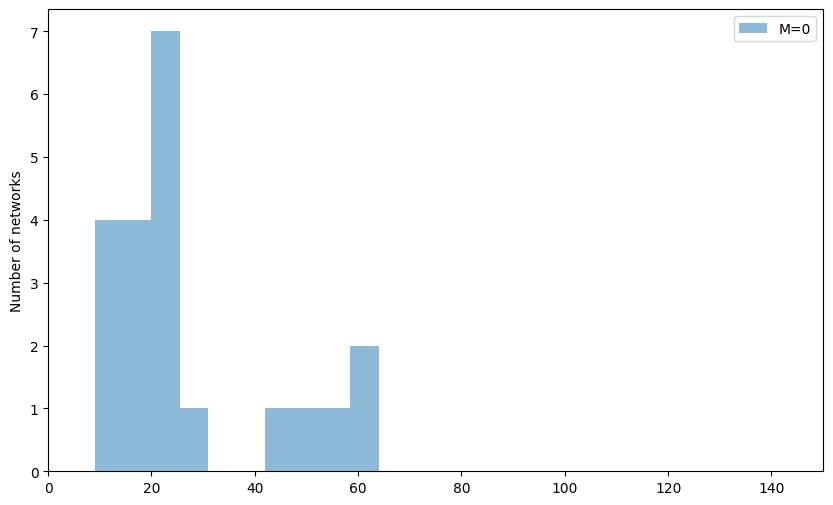

In [ ]:
plt.figure(figsize=(10,6))
#plt.hist(n_sign_conditions_by_M[0], bins=range(1, 11), alpha=0.5)
plt.hist(n_sign_conditions_by_M[6], alpha=0.5)
plt.ylabel('Number of networks')
plt.legend(['M=0', 'M=2', 'M=4', 'M=6', 'M=8', 'M=10'])
plt.xlim(0,150)
plt.show()

[10, 22, 6, 49, 2, 23, 19, 3, 4, 96, 95, 5, 67, 1, 13, 3, 2, 4, 2, 23, 68, 5, 2, 23, 17, 3, 90, 2, 8, 3, 4, 3, 2, 44, 19, 21, 3, 46, 3, 14, 3, 2, 5, 15, 15, 15, 2, 2, 17, 16, 3, 6, 21, 3, 3, 2, 1, 7, 5, 17, 5, 15, 2, 22, 1, 20, 1, 4, 14, 14, 1, 39, 9, 13, 4, 1, 1, 3, 12, 2, 2, 20, 17, 5, 4, 3, 2, 4, 6, 2, 4, 14, 3, 21, 4, 15, 24, 1, 12, 9, 1, 28, 30, 78, 10, 3, 41, 26, 18, 24, 7, 4, 39, 4, 5, 44, 3, 4, 24, 2, 28, 1, 16, 22, 20, 19, 3, 49, 15, 24, 6, 22, 15, 1, 4, 3, 3, 15, 11, 53, 108, 16, 64, 2, 11, 1, 14, 2, 3, 1, 8, 1, 4, 2, 3, 46, 2, 16, 11, 22, 1, 2, 2, 1, 3, 2, 1, 18, 17, 2, 1, 7, 15, 4, 56, 1, 4, 1, 13, 1, 2, 4, 4, 12, 11, 3, 5, 15, 3, 1, 59, 4, 49, 43, 2, 2, 19, 5, 6, 3, 10, 6, 1, 24, 5, 5, 1, 2, 13, 3, 3, 4, 14, 2, 2, 20, 6, 2, 27, 1, 4, 2, 1, 15, 3, 40, 20, 3, 24, 2, 8, 15, 2, 40, 2, 3, 4, 4, 2, 3, 19, 5, 1, 2, 12, 3, 17, 2, 2, 49, 1, 2, 2, 3, 13, 1, 3, 3, 25, 11, 3, 2, 5, 3, 2, 4, 7, 2, 2, 10, 2, 2, 2, 2, 1, 3, 2, 2, 3, 53, 18, 22, 6, 29, 12, 54, 14, 6, 7, 1, 1, 3, 2, 4, 2, 

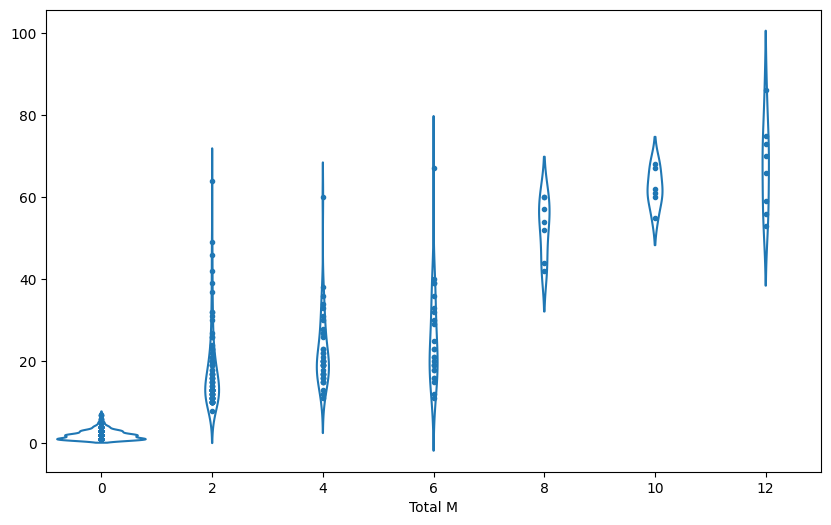

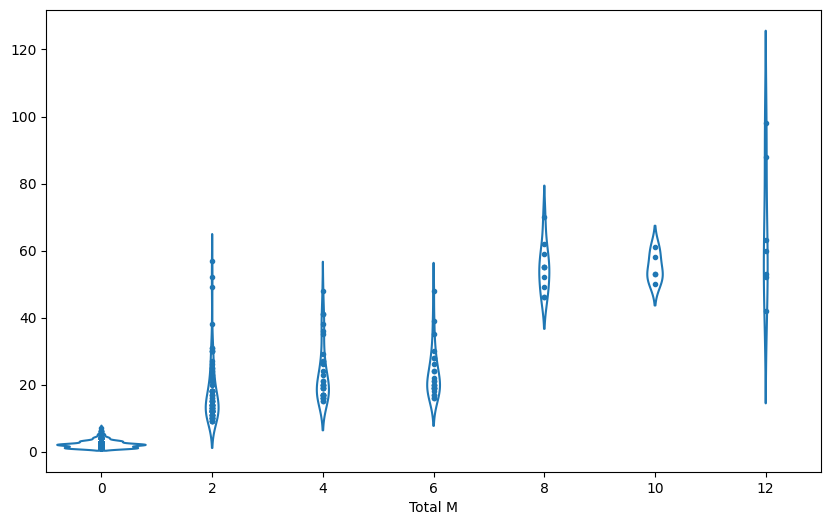

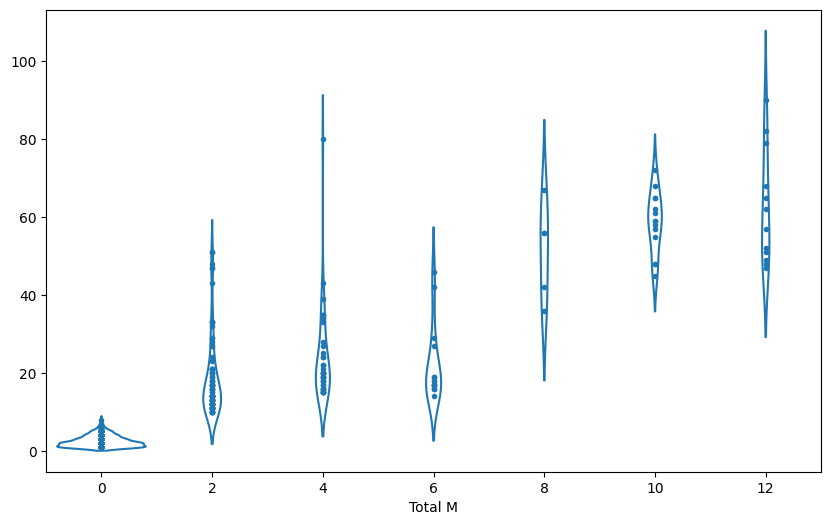

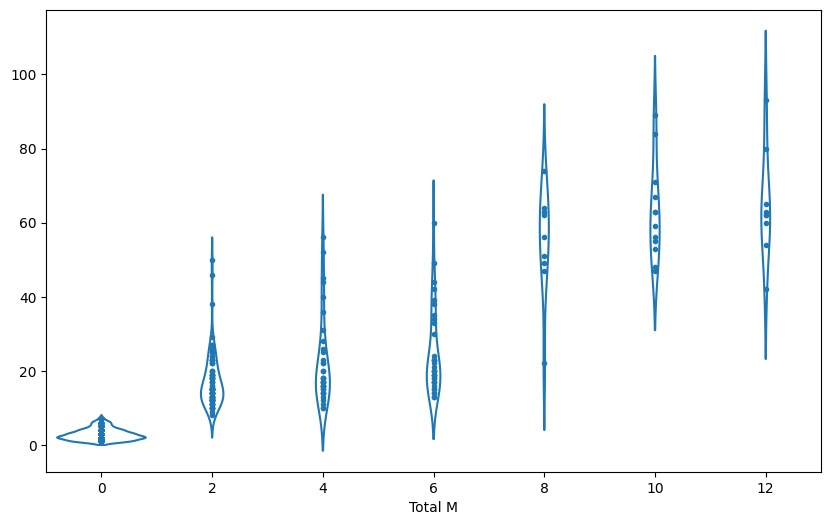

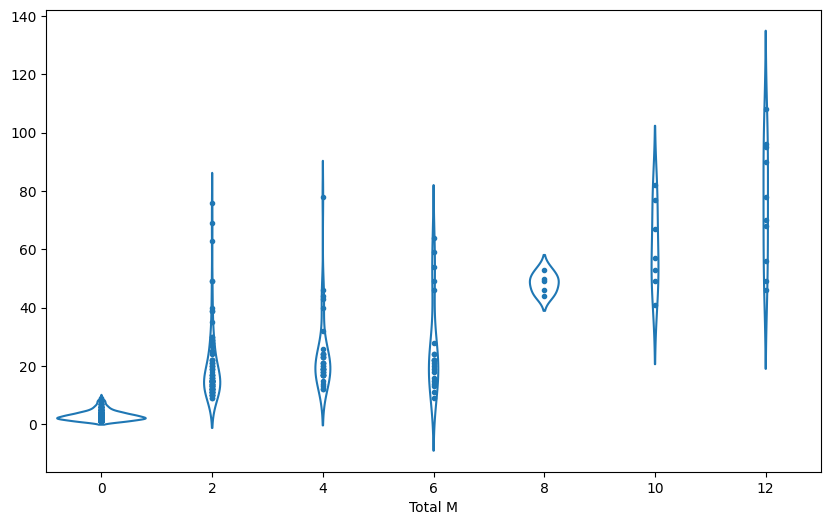

In [ ]:
print([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])
print(len(data_logger.network_data))



path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range_2"

vars = [0, 1, 2, 4, 5]
M_list = []

for var in vars:
    file = path + "/" + str(var) + "/SavedData.pkl"
    data_logger = NetworkDataLogger(file)
    M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
    n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

    plt.figure(figsize=(10,6))
    sns.violinplot(x=M_values, y=n_sign_conditions, inner = "point", fill = False)
    plt.xlabel('Total M')






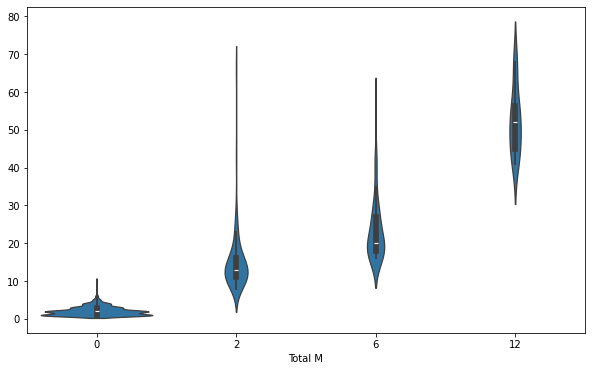

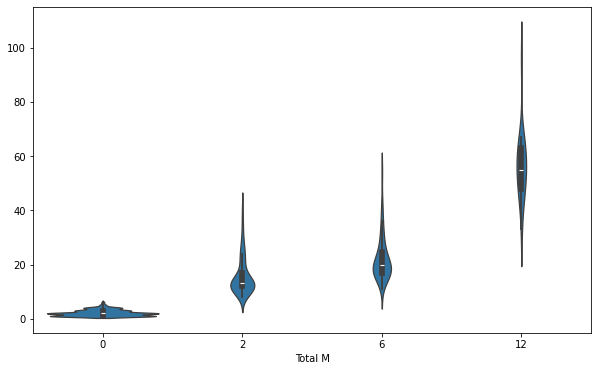

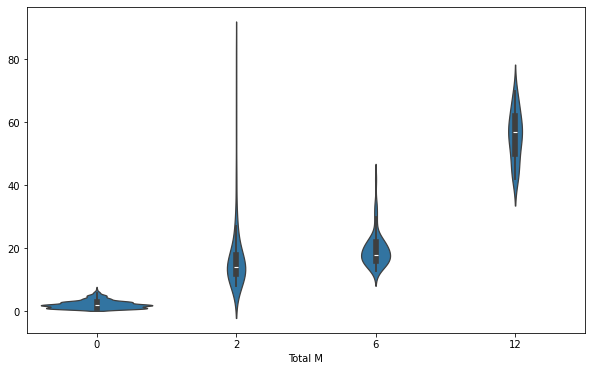

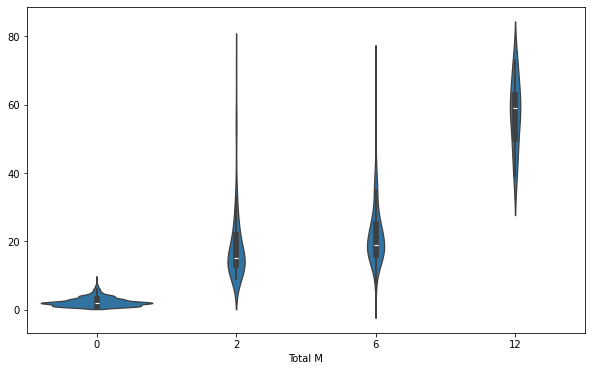

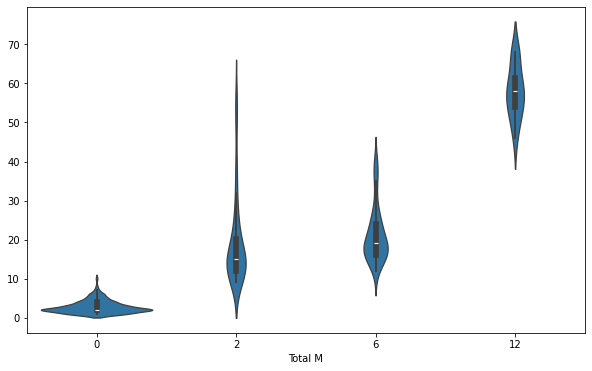

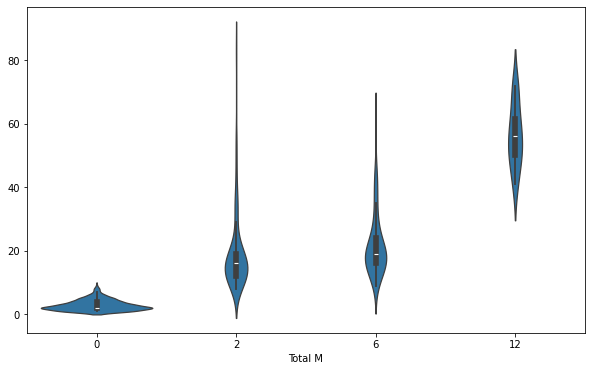

In [ ]:
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/F_range"

vars = [0, 1, 2, 3, 4, 5]
M_list = []

for var in vars:
    with open(path + "/" + str(var) + "/SavedData.pkl", "rb") as file:
        M_0t1_list, M_1t0_list, M_0b1_list, r_n_list, sign_conditions_list = pickle.load(file)

    M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)
    n_sign_conditions = np.array([len(s) for s in sign_conditions_list])

    plt.figure(figsize=(10,6))
    sns.violinplot(x=M_values, y=n_sign_conditions)
    plt.xlabel('Total M')

Sign conditions where M=12:
[16 17 10 14 15 12 11 14 14 10 11 16  8 25 18 11 19 49 14 12 14 17 18 18
 17 16 12 18 14 32 10 16 45 12 19 12 38 22 21 17 19 13 83 16 32 14  9 13
 12 13 35 13 56 16  9 12 16 34 36 18 29 11 20 21 11 35 11 14 15 11 17 18
 43 16 12 13 10 11 17 18 21 54 12 11 11  9 29 16 18 15 17 35 16 11 16 11
 24 12 17 15 21 22 16]
18.980582524271846


(array([47., 38.,  4.,  7.,  3.,  1.,  2.,  0.,  0.,  1.]),
 array([ 8. , 15.5, 23. , 30.5, 38. , 45.5, 53. , 60.5, 68. , 75.5, 83. ]),
 <BarContainer object of 10 artists>)

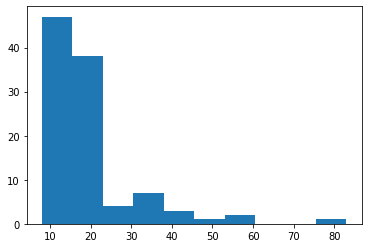

In [ ]:
with open(path + "/" + str(5) + "/SavedData.pkl", "rb") as file:
        M_0t1_list, M_1t0_list, M_0b1_list, r_n_list, sign_conditions_list = pickle.load(file)

M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)
n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
n_sign_conditions_12 = n_sign_conditions[M_values == 2]
print("Sign conditions where M=12:")
print(n_sign_conditions_12)
print(np.mean(n_sign_conditions_12))
plt.hist(n_sign_conditions_12)

Text(0, 0.5, 'Number of sign conditions')

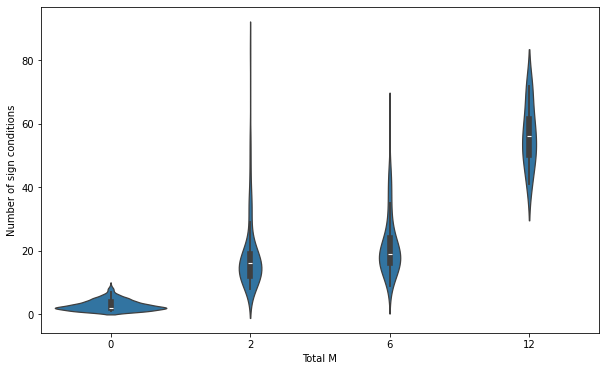

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

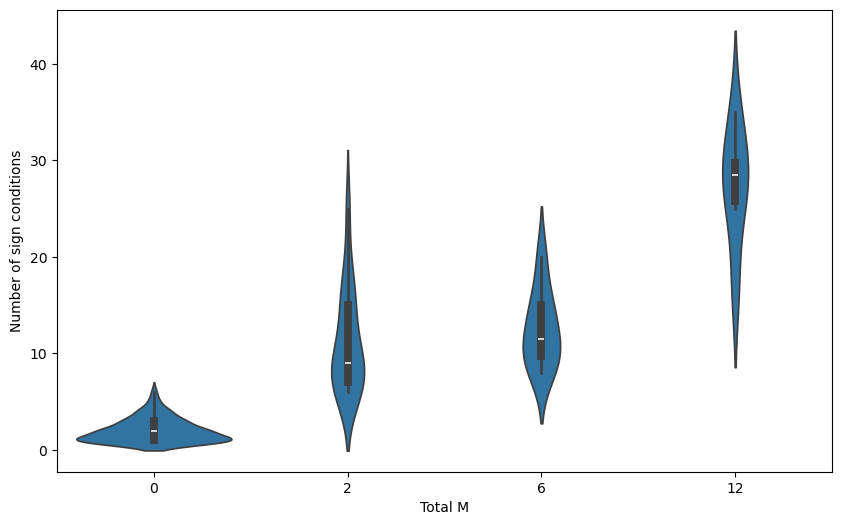

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import comb
import matplotlib.pyplot as plt
import warnings

def bezier_basis(n, k, x):
    x = np.asarray(x)
    result = np.zeros_like(x)
    mask_zero = (x == 0)
    if k == 0:
        result[mask_zero] = 1.0
    else:
        result[mask_zero] = 0.0
    mask_one = (x == 1)
    if k == n:
        result[mask_one] = 1.0
    else:
        result[mask_one] = 0.0
    mask_normal = ~(mask_zero | mask_one)
    if np.any(mask_normal):
        result[mask_normal] = comb(n, k) * (x[mask_normal]**k) * ((1-x[mask_normal])**(n-k))
    return result

def bezier_polynomial(x, coefficients, degree):
    y = np.zeros_like(x)
    for k, c_k in enumerate(coefficients):
        y += c_k * bezier_basis(degree, k, x)
    return y

def fit_bezier_polynomial_with_residuals(x_data, y_data, degree, normalize_x=True):
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    if normalize_x:
        x_min, x_max = x_data.min(), x_data.max()
        x_normalized = (x_data - x_min) / (x_max - x_min)
    else:
        x_normalized = x_data
        x_min, x_max = None, None
    def objective(coefficients):
        y_pred = bezier_polynomial(x_normalized, coefficients, degree)
        return np.sum((y_data - y_pred)**2)
    initial_coeffs = np.random.normal(0, 1, degree + 1)
    result = minimize(objective, initial_coeffs, method='BFGS')
    if not result.success:
        raise ValueError("Optimization failed: " + result.message)
    y_predicted = bezier_polynomial(x_normalized, result.x, degree)
    residuals = y_data - y_predicted
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    r_squared = 1 - (ss_res / ss_tot)
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    return {
        'coefficients': result.x,
        'residuals': residuals,
        'y_predicted': y_predicted,
        'r_squared': r_squared,
        'mse': mse,
        'rmse': rmse,
        'x_normalized': x_normalized,
        'x_min': x_min,
        'x_max': x_max,
        'ss_res': ss_res,
        'ss_tot': ss_tot
    }

max_degree = 10
degrees = range(1, max_degree + 1)
squared_residuals = []
r_squared_values = []
fit_results = {}

for degree in degrees:
    try:
        result = fit_bezier_polynomial_with_residuals(x_vals, y_vals, degree)
        fit_results[degree] = result
        squared_residuals.append(result['ss_res'])
        r_squared_values.append(result['r_squared'])
        print(f"Degree {degree}: SS_res = {result['ss_res']:.12f}, R² = {result['r_squared']:.4f}")
    except Exception as e:
        print(f"Degree {degree} failed: {e}")
        squared_residuals.append(np.nan)
        r_squared_values.append(np.nan)

plt.figure(figsize=(15, 10))

n_cols = 3
n_rows = 4
for i, degree in enumerate(degrees):
    plt.subplot(n_rows, n_cols, i + 1)
    
    if degree in fit_results:
        result = fit_results[degree]
        plt.scatter(x_vals, y_vals, alpha=0.6, color='blue', s=20, label='Data')
        
        x_plot = np.linspace(result['x_min'], result['x_max'], 1000)
        x_plot_norm = (x_plot - result['x_min']) / (result['x_max'] - result['x_min'])
        y_plot = bezier_polynomial(x_plot_norm, result['coefficients'], degree)
        plt.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Degree {degree}')
        
        plt.title(f'Degree {degree}\nR² = {result["r_squared"]:.3f}')
        plt.grid(True, alpha=0.3)
        if i == 0:
            plt.legend(fontsize=8)
    else:
        plt.text(0.5, 0.5, f'Degree {degree}\nFailed', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'Degree {degree} - Failed')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(degrees, squared_residuals, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Bézier Order')
plt.ylabel('Total Squared Residual')
plt.title('Squared Residual vs Bézier Order')
plt.grid(True, alpha=0.3)
#plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(degrees, r_squared_values, 'ro-', linewidth=2, markersize=6)
plt.xlabel('Bézier Order')
plt.ylabel('R²')
plt.title('R² vs Bézier Order')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

best_degree_idx = np.nanargmin(squared_residuals)
best_degree = degrees[best_degree_idx]
print(f"Best degree: {best_degree} with SS_res = {squared_residuals[best_degree_idx]:.12f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_derivatives_raw_data(x_vals, y_vals, max_derivative=4):
    """
    Compute derivatives directly from raw data using finite differences
    
    Parameters:
    x_vals: input data
    y_vals: output data
    max_derivative: maximum derivative order to compute
    
    Returns:
    dict with derivatives and zeros
    """
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)
    
    # Sort data by x values
    sort_idx = np.argsort(x_vals)
    x_sorted = x_vals[sort_idx]
    y_sorted = y_vals[sort_idx]
    
    # Compute derivatives using finite differences
    derivatives = {}
    zeros = {}
    
    # 0th derivative (original function)
    derivatives[0] = {'x': x_sorted, 'y': y_sorted}
    
    # Current data for derivative computation
    current_x = x_sorted.copy()
    current_y = y_sorted.copy()
    
    for order in range(1, max_derivative + 1):
        # Compute finite differences
        if len(current_y) < 2:
            break
            
        # Forward differences
        dx = np.diff(current_x)
        dy = np.diff(current_y)
        
        # Derivative = dy/dx
        deriv_y = dy / dx
        
        # x values for derivative (midpoints)
        deriv_x = (current_x[:-1] + current_x[1:]) / 2
        
        # Store derivative
        derivatives[order] = {'x': deriv_x, 'y': deriv_y}
        
        # Find zeros in this derivative
        zeros[order] = find_zeros_finite_difference(deriv_x, deriv_y)
        
        # Update for next derivative
        current_x = deriv_x
        current_y = deriv_y
    
    return {
        'derivatives': derivatives,
        'zeros': zeros,
        'x_original': x_sorted,
        'y_original': y_sorted
    }

def find_zeros_finite_difference(x, y):
    """
    Find zeros in y using sign changes
    """
    zeros = []
    
    for i in range(len(y) - 1):
        if y[i] * y[i+1] < 0:  # Sign change
            # Linear interpolation to find zero
            x_zero = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            zeros.append(x_zero)
    
    return np.array(zeros)

def plot_derivatives_raw_data(result, max_derivative=4):
    """
    Plot derivatives computed from raw data
    """
    derivatives = result['derivatives']
    zeros = result['zeros']
    x_original = result['x_original']
    y_original = result['y_original']
    
    # Create subplots
    n_plots = min(max_derivative + 1, len(derivatives))
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3 * n_plots))
    
    if n_plots == 1:
        axes = [axes]
    
    for order in range(n_plots):
        ax = axes[order]
        
        if order in derivatives:
            deriv_data = derivatives[order]
            
            # Plot derivative
            ax.plot(deriv_data['x'], deriv_data['y'], 'b-', linewidth=2, 
                   marker='o', markersize=3, label=f'f^({order})')
            
            # Mark zeros
            if order in zeros and len(zeros[order]) > 0:
                ax.scatter(zeros[order], np.zeros_like(zeros[order]), 
                          color='red', s=50, zorder=5, label=f'Zeros ({len(zeros[order])})')
            
            # Plot original data points for 0th derivative
            if order == 0:
                ax.scatter(x_original, y_original, color='green', s=30, alpha=0.7, label='Data')
            
            ax.set_xlabel('x')
            ax.set_ylabel(f'f^({order})')
            ax.set_title(f'Derivative of order {order} (from raw data)')
            ax.grid(True, alpha=0.3)
            ax.legend()
        else:
            ax.text(0.5, 0.5, f'Derivative {order} not available', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Derivative of order {order} (not available)')
    
    plt.tight_layout()
    plt.show()
    
    # Print zero locations
    print("\n=== Zero Locations ===")
    for order in range(1, max_derivative + 1):
        if order in zeros and len(zeros[order]) > 0:
            print(f"f^({order}) zeros at x = {zeros[order]}")
        else:
            print(f"f^({order}) has no zeros in the domain")

def analyze_derivative_behavior_raw(result):
    """
    Analyze the behavior of derivatives from raw data
    """
    derivatives = result['derivatives']
    
    print("\n=== Derivative Analysis (Raw Data) ===")
    
    for order in range(len(derivatives)):
        if order in derivatives:
            deriv_data = derivatives[order]
            deriv_y = deriv_data['y']
            
            print(f"\nf^({order}):")
            print(f"  Data points: {len(deriv_y)}")
            print(f"  Range: [{deriv_y.min():.6f}, {deriv_y.max():.6f}]")
            print(f"  Mean: {deriv_y.mean():.6f}")
            print(f"  Std: {deriv_y.std():.6f}")
            
            # Find extrema (where derivative is close to zero)
            if order > 0:
                zero_threshold = 0.1 * np.std(deriv_y)
                extrema_mask = np.abs(deriv_y) < zero_threshold
                if np.any(extrema_mask):
                    extrema_x = deriv_data['x'][extrema_mask]
                    print(f"  Extrema of f^({order-1}) at x ≈ {extrema_x}")

# Example usage:
print("=== Computing Derivatives from Raw Data ===")

# Compute derivatives from raw data
result = compute_derivatives_raw_data(x_vals, y_vals, max_derivative=4)

# Plot results
plot_derivatives_raw_data(result, max_derivative=4)

# Analyze behavior
analyze_derivative_behavior_raw(result)

Text(0, 0.5, 'Number of sign conditions')

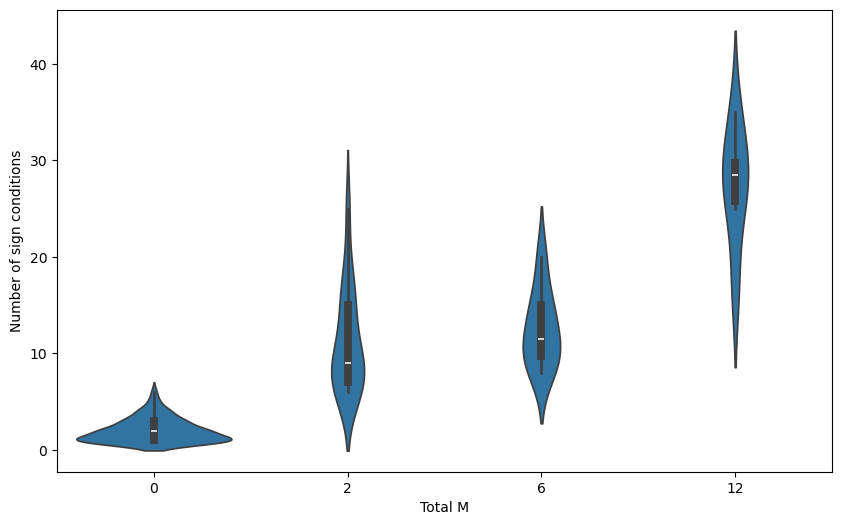

In [ ]:

    
# Scan MLP widths
# print("=== MLP Results ===")
# mlp_results, mlp_ss_res, mlp_r2, mlp_n_params, mlp_widths = scan_mlp_widths(x_vals, y_vals, max_width=10, normalize_x=True)

result = select_best_mlp_width(x_vals, y_vals, width_range=(2, 10), normalize_x=True, r2_threshold = 0.999, quiet = True)
print(result['best_width'])
# # Plot MLP fits
# plot_mlp_fits(x_vals, y_vals, mlp_results, max_show=9)

# # Calculate AIC and BIC
# n_data = len(x_vals)
# aic_values = []
# bic_values = []

# # Calculate AIC and BIC with proper parameter counting
# n_data = len(x_vals)
# aic_values = []
# bic_values = []

# for i, width in enumerate(mlp_widths):
#     if width in mlp_results:
#         result = mlp_results[width]
#         k = result['n_params']  # This already counts all weights + biases
#         aic = n_data * np.log(result['ss_res'] / n_data) + 2 * k
#         bic = n_data * np.log(result['ss_res'] / n_data) + k * np.log(n_data)
#         aic_values.append(aic)
#         bic_values.append(bic)
#     else:
#         aic_values.append(np.inf)
#         bic_values.append(np.inf)

# # Find best models
# best_ss_idx = np.argmin(mlp_ss_res)
# best_aic_idx = np.argmin(aic_values)
# best_bic_idx = np.argmin(bic_values)

# best_ss_width = mlp_widths[best_ss_idx]
# best_aic_width = mlp_widths[best_aic_idx]
# best_bic_width = mlp_widths[best_bic_idx]

# print(f"\nBest width by SS_res: {best_ss_width}")
# print(f"Best width by AIC: {best_aic_width}")
# print(f"Best width by BIC: {best_bic_width}")

# Plot comparison
# plt.figure(figsize=(15, 5))

# plt.subplot(1, 3, 1)
# plt.plot(mlp_widths, mlp_ss_res, 'bo-', linewidth=2, markersize=6)
# plt.axvline(x=best_ss_width, color='red', linestyle='--', label=f'Best: {best_ss_width}')
# plt.xlabel('MLP Width')
# plt.ylabel('Squared Residual')
# plt.title('Squared Residual vs MLP Width')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.yscale('log')

# plt.subplot(1, 3, 2)
# plt.plot(mlp_widths, aic_values, 'go-', linewidth=2, markersize=6)
# plt.axvline(x=best_aic_width, color='red', linestyle='--', label=f'Best: {best_aic_width}')
# plt.xlabel('MLP Width')
# plt.ylabel('AIC')
# plt.title('AIC vs MLP Width')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(1, 3, 3)
# plt.plot(mlp_widths, bic_values, 'mo-', linewidth=2, markersize=6)
# plt.axvline(x=best_bic_width, color='red', linestyle='--', label=f'Best: {best_bic_width}')
# plt.xlabel('MLP Width')
# plt.ylabel('BIC')
# plt.title('BIC vs MLP Width')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Plot R² vs width
# plt.figure(figsize=(8, 5))
# plt.plot(mlp_widths, mlp_r2, 'ro-', linewidth=2, markersize=6)
# plt.xlabel('MLP Width')
# plt.ylabel('R²')
# plt.title('R² vs MLP Width')
# plt.grid(True, alpha=0.3)
# plt.ylim(0, 1)

# plt.tight_layout()
# plt.show()

# # Show parameter count vs width
# plt.figure(figsize=(8, 5))
# plt.plot(mlp_widths, mlp_n_params, 'ko-', linewidth=2, markersize=6)
# plt.xlabel('MLP Width')
# plt.ylabel('Number of Parameters')
# plt.title('Parameters vs MLP Width')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()